In [2]:
%load_ext autoreload
%autoreload 2

# Network Scoring

This notebook will show how to score individual learning events accross trials for a given experiment/optimizer run. These score metrics will then be aggregate to compare accross optimizers/experiments.

In [ ]:
import sys
from pathlib import Path
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import seaborn as sns
import torch
from IPython.display import display
from tqdm.auto import tqdm
import json


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

pio.renderers.default = "notebook"
pio.templates.default = "plotly_white"
import visualize_webapp.app as _vwa

# White backgrounds (app builders use transparent _style(); dark notebook themes need this).
if not hasattr(_vwa, "_style_original"):
	_vwa._style_original = _vwa._style


def _style_white_bg(fig, **kw):
	_vwa._style_original(fig, **kw)
	fig.update_layout(paper_bgcolor="white", plot_bgcolor="white")
	return fig


_vwa._style = _style_white_bg

import models.dnn_5_hidden_64  # noqa: F401
import models.cnn_3conv_k5_out32_then_fc32  # noqa: F401
from experiments.mnist import MNISTWrapper
from models import get_model

from visualize_webapp.app import (
	scan_results,
	_metrics,
	_nts,
	_compact_neuron_label,
	_build_layer_inactive_count,
	_build_layer_digit_count_plot,
	_build_layer_digit_count_non_head_combined,
	_build_recovery_cumsum_plot,
	_build_dead_layer_traces,
	_build_dead_neuron_pre_nl_grid,
	_build_dead_neuron_inactivity_bar,
	_NETWORK_N_DIGITS,
	_NETWORK_SAMPLES_PER_DIGIT,
	_NETWORK_EVAL_K_LINE_COLORS,
	C,
)
from visualize_webapp.notebook.network_analysis_mpl import (
	mpl_dead_layer_traces,
	mpl_layer_digit_count_non_head_combined,
	mpl_layer_digit_count_plot,
	mpl_layer_inactive_count,
	mpl_neuron_assigned_digit_count_over_time,
	mpl_neuron_eval_activation_angle_over_time,
	mpl_neuron_eval_activation_mean_over_time,
	mpl_recovery_cumsum,
	mpl_neuron_eval_activation_per_sample_over_time
)
from analysis.rdx import compute_G, distance_to_rank
from analysis.scoring_constants import (
	MNIST_IMAGE_SHAPE,
	N_SAMPLES_PER_TRIAL,
	PYRAMID_LEVELS,
	USE_CW_SSIM,
	WAVELET_ORIENTATIONS,
)
from analysis.scoring_helpers import (
	angle_score_function,
	compute_repr_sim_factor,
	filter_periods,
	find_impacted_periods,
	find_target_checkpoint,
	get_all_cross_sample_distances,
	get_all_model_saliency_maps,
	get_all_points_of_max_acceleration,
	get_all_saliency_maps,
	get_assignments,
	get_assigned_digits_for_trial_activations,
	get_iteration,
	get_layer_baselines,
	get_neuron_saliency_maps_from_all,
	get_normalize_ssims,
	get_n_assigned_digits,
	get_period_angles,
	get_period_checkpoint_indices,
	get_period_data,
	get_period_mssims,
	get_recovery_periods,
	get_period_scores_through_time,
	get_repr_similiraity_scores,
	get_trial_neuron_activations,
	get_trial_start_end_iter,
	get_trial_starts,
	init_cw_ssim_pyramid,
	length_score_function,
	n_active_decay,
	n_partial_decay,
	point_of_max_acceleration,
	remove_inelligible_periods,
	repr_similarity_score_function,
	sample_ics_for_digits,
	sample_idcs_for_digit,
	summarize_through_time_metrics,
	index_grp,
)
from visualize_webapp.post_processing import (
	_pp_dead,
	_pp_neuron_digit,
	_pp_train_act,
	per_neuron_recovery_counts,
	split_ever_dead_by_final_checkpoint,
)

SCORE_FACTORS = {
	"angle_score": 3.0,
	"length_score": 2.0,
	"n_partial_decay_score": 0.1,
	"n_active_decay_score": 0.1,
	"repr_similarity_score": 3.0,
}
COMPUTATION_POINT = "max_activity"
EXPERT_MODEL_DIR = "local/save/expert_optimizer_pretrained/!OPT/"
STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True


In [4]:
PLOTS_DIR = Path("/home/garvalov/thesis/plateau_optimizer/network_analyzer/visualize_webapp/notebook/local/save/plots")

## Configuration

Set the four identifiers below to select which run to analyse.
Run the **Discovery** cell first if you are unsure of the exact string values.

In [5]:
tree = scan_results()
for eid, models in sorted(tree.items()):
	for mid, runs in sorted(models.items()):
		for rid, oids in sorted(runs.items()):
			for oid in oids:
				print(f"  experiment={eid!r}  model={mid!r}  run={rid!r}  optimizer={oid!r}")

  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='sgd_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adagrad_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adam_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='pure_shampoo_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='grafted_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='sgd_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adagrad_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adam_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='pure_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  ru

In [ ]:
# __ CONFIG ____________________________________________________________
MODEL_ID	  = "dnn_5x64"
EXPERIMENT_ID = "pretrain_0_mislabel1_1_K1000_tr100" # trick to change the results dir from results/ to results_old/
RUN_ID		= "4a7338"
OPTIMIZER_ID  = "grafted_shampoo_lr0.01"

USE_BOXPLOT = False
# When True, sections above "Dead neuron detail" use matplotlib instead of Plotly.
USE_MATPLOTLIB = True


SHOW_PLOTS = True
# ____________________________________________________________________________

N_SAMPLES_PER_EVALUATION_DIGIT = 5
N_SAMPLES_PER_TRIAL = 100

# ____________________________________________________________________________

## Data loading

In [7]:
metrics = _metrics(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)

df_nd = cast(pd.DataFrame, _pp_neuron_digit(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False))
if df_nd is None or df_nd.empty:
	print("WARNING: post_processing_neuron_digit.csv not found for this run.")
	print("Re-run training to generate post-processing data.")
else:
	df_nd = df_nd.copy()
	df_nd["n_active"] = df_nd["status"].apply(
		lambda s: 0 if s == "inactive" else (_NETWORK_SAMPLES_PER_DIGIT if s == "assigned" else int(s.split("_")[-1]))
	)
	df_nd["iteration"] = df_nd["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))
	layer_order = list(dict.fromkeys(df_nd["layer_name"].tolist()))
	print(f"Layers: {layer_order}")

df_dead = cast(pd.DataFrame, _pp_dead(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False))
if df_dead is None or df_dead.empty:
	ever_dead_nids = []
	dead_at_end_nids = set()
	recovered_dead_nids = set()
	print("No dead-neuron data found.")
else:
	df_dead = df_dead.copy()
	df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))
	ever_dead_nids = sorted(df_dead[df_dead["is_dead"]]["neuron_id"].unique().tolist())
	dead_at_end_nids, recovered_dead_nids = split_ever_dead_by_final_checkpoint(df_dead)
	print(f"Dead neurons ({len(ever_dead_nids)}): {ever_dead_nids}")
	print(f"  Still dead at last checkpoint (perpetually dead at end): {len(dead_at_end_nids)}")
	print(f"  Recovered dead (alive at last checkpoint): {len(recovered_dead_nids)}")

pp_ta = _pp_train_act(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
nts = _nts(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)


Layers: ['hidden.0', 'hidden.2', 'hidden.4', 'hidden.6', 'hidden.8', 'head']
Dead neurons (56): ['dnn|hidden.0|neuron|1', 'dnn|hidden.0|neuron|17', 'dnn|hidden.0|neuron|26', 'dnn|hidden.0|neuron|29', 'dnn|hidden.0|neuron|31', 'dnn|hidden.0|neuron|33', 'dnn|hidden.0|neuron|35', 'dnn|hidden.0|neuron|38', 'dnn|hidden.0|neuron|39', 'dnn|hidden.0|neuron|5', 'dnn|hidden.0|neuron|50', 'dnn|hidden.0|neuron|54', 'dnn|hidden.2|neuron|10', 'dnn|hidden.2|neuron|19', 'dnn|hidden.2|neuron|35', 'dnn|hidden.2|neuron|39', 'dnn|hidden.2|neuron|42', 'dnn|hidden.2|neuron|52', 'dnn|hidden.2|neuron|57', 'dnn|hidden.4|neuron|10', 'dnn|hidden.4|neuron|16', 'dnn|hidden.4|neuron|2', 'dnn|hidden.4|neuron|20', 'dnn|hidden.4|neuron|21', 'dnn|hidden.4|neuron|33', 'dnn|hidden.4|neuron|43', 'dnn|hidden.4|neuron|46', 'dnn|hidden.4|neuron|50', 'dnn|hidden.4|neuron|52', 'dnn|hidden.4|neuron|61', 'dnn|hidden.4|neuron|8', 'dnn|hidden.6|neuron|16', 'dnn|hidden.6|neuron|18', 'dnn|hidden.6|neuron|23', 'dnn|hidden.6|neuron|26

In [8]:
print("df_nd")
display(df_nd.head(5))
print("df_dead")
display(df_dead.head(5))

df_nd


,neuron_id,layer_name,checkpoint_idx,checkpoint_tag,digit,status,n_active,iteration
0,dnn|hidden.0|neuron|0,hidden.0,0,init,0,inactive,0,0
1,dnn|hidden.0|neuron|0,hidden.0,0,init,1,assigned,5,0
2,dnn|hidden.0|neuron|0,hidden.0,0,init,2,partial_1,1,0
3,dnn|hidden.0|neuron|0,hidden.0,0,init,3,inactive,0,0
4,dnn|hidden.0|neuron|0,hidden.0,0,init,4,partial_1,1,0


df_dead


,neuron_id,layer_name,checkpoint_idx,checkpoint_tag,is_dead,is_ppd,iteration
0,dnn|hidden.0|neuron|0,hidden.0,0,init,False,False,0
1,dnn|hidden.0|neuron|0,hidden.0,1,tsw_run0_trial_digit0_entry,False,False,0
2,dnn|hidden.0|neuron|0,hidden.0,2,tsw_run0_trial_digit0_iter1,False,False,1
3,dnn|hidden.0|neuron|0,hidden.0,3,tsw_run0_trial_digit0_iter2,False,False,2
4,dnn|hidden.0|neuron|0,hidden.0,4,tsw_run0_trial_digit0_iter3,False,False,3


# BTSP event identification

As a first step, we want to label "BTSP-like events" during learning of our experiment. We define a "BTSP-like" event as an event that matches the following 2 know features of BTSP:

1. BTSP increases FR
2. BTSP recruits new neurons

In ANNs, this translates to:

1. There is an increase in a neuron post non-linearity activation
2. The neuron's initial state is “inactive” with respect to the task

We define activity based on the neuron's response on an evaluation set: inactive neurons for the task are the dead neurons (wrt the evaluation set). See `compute_results/post_processing.py`

Naturally, a neuron can see an increase in FR on several digits. An ideal BTSP-event would be compose of a neuron seeing a spike in activity for one digit and for no other digits. This neuron would then specialize to (some feature) of that digit, and ideally this feature would be unique to this digit; hence the neuron would not respond to any other digits. A neuron that would respond to all samples of D>1 digits might've learned a feature that is common accross different digits, which is also alright, but less preferred (e.g.: if we place a reward in two different rooms at the same place, it is ok if the same place cells get recruited). 
In less ideal scenarios, it might be that a neuron becomes assigned to some digit, but responds to only a subset of the K=5 samples of some other digit(s). While a suddent assignment can be related to BTSP, a partial activity on other digits (which follow the same distribution) is unrealistic and a sign that the feature learnt is unstable.

We thus rank the likeliness of "BTSP events" according the: 
1. The number of partially active digits (less (e.g.: 0) is better)
2. The number of assigned to digits (less (e.g. 1) means more specialized -> closer to a "place field")



## 1. Identify periods

In [9]:
# Get the assigned neurons
assigned_neurons = df_nd.loc[df_nd["status"] == "assigned", ["neuron_id", "layer_name", "checkpoint_idx", "digit", "status", "n_active"]]
dead_neurons = df_dead.loc[df_dead["is_dead"], ["neuron_id", "layer_name", "checkpoint_idx"]]

n_assigned_digits = get_n_assigned_digits(df_nd)
display(n_assigned_digits.head(5))


neuron_id              checkpoint_idx
dnn|hidden.0|neuron|0  0                 2
                       1                 2
                       2                 2
                       3                 2
                       4                 2
Name: n_assigned_digits, dtype: int64

In [10]:
MODE = "assigned_same"

recovery_periods_any = get_recovery_periods(metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_any")
recovery_periods_same = get_recovery_periods(metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same")
print(f"Total recovery periods: {len(recovery_periods_any)}")
print(f"Open periods (still assigned at last ckpt): {recovery_periods_any['end'].isna().sum()}")


Total recovery periods: 26
Open periods (still assigned at last ckpt): 5


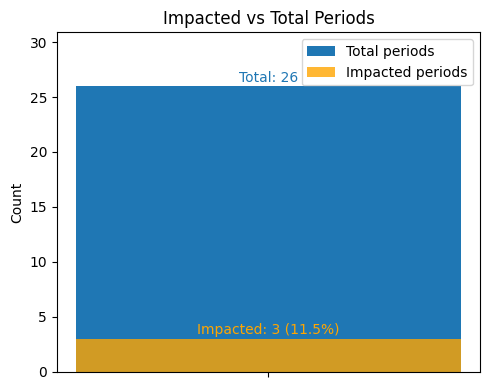

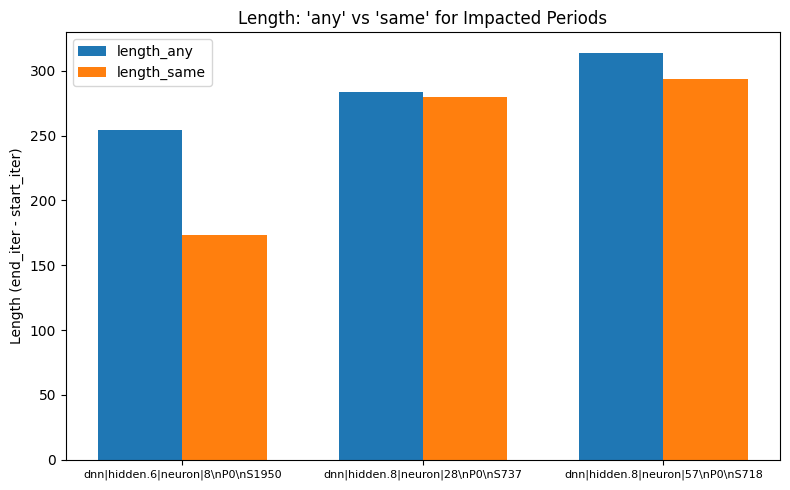

In [11]:
def maybe_plot(impacted: pd.DataFrame | None, num_periods: int):
	if impacted is None:
		return

	# Plot 1: Overlapping bar graph showing the proportion of impacted/total periods.
	fig, ax = plt.subplots(figsize=(5, 4))
	n_impacted = len(impacted)
	prop = n_impacted / num_periods if num_periods else 0
	x = np.arange(1)
	ax.bar(x, [num_periods], width=0.4, label="Total periods")
	ax.bar(x, [n_impacted], width=0.4, label="Impacted periods", alpha=0.8, color="orange")
	ax.set_ylim(0, max(num_periods, n_impacted) * 1.15 + 1)
	ax.set_xticks(x)
	ax.set_xticklabels([""])
	ax.set_ylabel("Count")
	ax.set_title("Impacted vs Total Periods")
	ax.legend()
	ax.text(0, num_periods + 0.1, f"Total: {num_periods}", ha="center", va="bottom", color="tab:blue")
	ax.text(0, n_impacted + 0.1, f"Impacted: {n_impacted} ({prop:.1%})", ha="center", va="bottom", color="orange")
	plt.tight_layout()
	plt.show()

	# Plot 2: Bar graph for each neuron/period start, two bars ("any", "same") on x-axis.
	x_labels = [f"{idx[0]}\\nP{idx[1]}\\nS{idx[2]}" for idx in impacted.index]
	x = np.arange(len(impacted))
	width = 0.35
	start_iters = [idx[2] for idx in impacted.index]
	length_any = impacted["end_iter_any"].values - np.array(start_iters)
	length_same = impacted["end_iter_same"].values - np.array(start_iters)

	fig, ax = plt.subplots(figsize=(max(8, len(x_labels) * 0.7), 5))
	ax.bar(x - width / 2, length_any, width, label="length_any")
	ax.bar(x + width / 2, length_same, width, label="length_same")
	ax.set_xticks(x)
	ax.set_xticklabels(x_labels, ha="center", fontsize=8)
	ax.set_ylabel("Length (end_iter - start_iter)")
	ax.set_title("Length: 'any' vs 'same' for Impacted Periods")
	ax.legend()
	plt.tight_layout()
	plt.show()


PLOT_IMPACTED = True
maybe_plot(
	find_impacted_periods(recovery_periods_any, recovery_periods_same, return_PRINT=not PLOT_IMPACTED),
	len(recovery_periods_any),
)


### 1.1 Select period-identification strategy

#### 1.1.1 Lengths

We have two period-identification strategies to identify the length of a period: `assigned_any` and `assigned_same`. They are both documented in the  `get_recovery_periods()` function. In short:

**assigned_any**: For each neuron, we qualify only periods in training where 
* the neuron is originally dead
* the neuron becomes assigned to a (set of) digit(s) 

The period stop whenever the neuron is not assigned to any digit anymore (but it can still be partially active).

This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)
	
**assigned_same**: For each neuron, we qualify only periods in training where 
* the neuron is originally dead
* the neuron becomes assigned to a (set of) digit(s) D

The period stop whenever the neuron is not assigned to the any of the digits in D anymore.

This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)


In [12]:
recovery_periods = recovery_periods_same # or recovery_periods_any
display(recovery_periods.head(30))

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126
5,dnn|hidden.4|neuron|46,hidden.4,0,1085,1234.0,1074,1221,147
6,dnn|hidden.4|neuron|46,hidden.4,1,2567,NaN,2541,3000,459
7,dnn|hidden.4|neuron|52,hidden.4,0,1560,1630.0,1544,1613,69
8,dnn|hidden.6|neuron|16,hidden.6,0,1277,1319.0,1264,1305,41
9,dnn|hidden.6|neuron|38,hidden.6,0,1067,1222.0,1056,1209,153


In [13]:
# get_period_data is imported from scoring_helpers.


##### Rmove ineligible periods 

Remove the identified BTSP events that do not last until at least the end of their trial


In [14]:
recovery_periods = remove_inelligible_periods(recovery_periods)


Removing 1 period(s) that do not last until the end of their trial.
Removing: neuron_id            dnn|hidden.8|neuron|49
layer_name                         hidden.8
period_id                                 0
start                                  1019
end                                  1037.0
start_iter                             1008
end_iter                               1026
total_length_iter                        18
Name: 22, dtype: object



#### 1.1.2 BTSP "start"

We have too strategies to identify the true "start" of a BTSP 

In [15]:
# Shared index columns used by scoring_helpers.
index_grp


['neuron_id', 'period_id']

In [16]:
# Helper function imported from analysis.scoring_helpers.


In [17]:
# Helper function imported from analysis.scoring_helpers.


In [18]:
# Helper function imported from analysis.scoring_helpers.


In [19]:
# Helper function imported from analysis.scoring_helpers.


In [20]:
# Helper function imported from analysis.scoring_helpers.


In [21]:
point_of_max_acceleration(nts,recovery_periods,"dnn|hidden.4|neuron|52",0)

19

In [22]:
points_of_max_acceleration = get_all_points_of_max_acceleration(nts, recovery_periods)
points_of_max_acceleration.head()


,,point_of_max_acceleration,delay_from_trial_start
neuron_id,period_id,,
dnn|hidden.2|neuron|19,0,4,51
dnn|hidden.2|neuron|42,0,10,11
dnn|hidden.4|neuron|10,0,2,10
dnn|hidden.4|neuron|20,0,4,17
dnn|hidden.4|neuron|43,0,13,18


In [23]:
def plot_all_points_of_max_acceleration(points_of_max_acceleration):
	df_reset = points_of_max_acceleration.reset_index()
	df_reset["proximity_to_assignment_pct"] = ( df_reset["point_of_max_acceleration"]/df_reset["delay_from_trial_start"] * 100)
	df_reset = df_reset.sort_values(by="proximity_to_assignment_pct")	
	fig, axs = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]})
	
	# --- First plot: Boxplot of point_of_max_acceleration
	axs[0].boxplot(df_reset["point_of_max_acceleration"].values, vert=True, patch_artist=True, showmeans=True, showfliers=True)
	axs[0].set_ylabel("Point of Max Acceleration")
	axs[0].set_title("Distribution of Point of Max Acceleration Across All Periods")
	axs[0].set_xticks([])	
	df_reset["period_label"] = df_reset["neuron_id"].astype(str) + "|p" + df_reset["period_id"].astype(str)
	bar_width = 0.4
	x = np.arange(len(df_reset["period_label"]))
	
	# First set of bars: proximity_to_assignment_pct
	bars1 = axs[1].bar(x - bar_width/2, df_reset["proximity_to_assignment_pct"], width=bar_width, color='tab:blue', alpha=0.7, label='Proximity to Assignment (%)')
	# Second set of bars: absolute point_of_max_acceleration
	bars2 = axs[1].bar(x + bar_width/2, df_reset["point_of_max_acceleration"], width=bar_width, color='tab:orange', alpha=0.7, label='Point of Max Acceleration')
	
	axs[1].set_ylabel("Proximity / Point of Max Acceleration")
	axs[1].set_title("Proximity to Assignment and Point of Max Acceleration Per Period")
	axs[1].set_xticks(x)
	axs[1].set_xticklabels(df_reset["period_label"], rotation=85, fontsize=7)
	axs[1].set_xlabel("Period (neuron_id|period_id)")
	axs[1].legend()
	
	# Annotate values above both sets of bars
	for bar, label in zip(bars1, df_reset["proximity_to_assignment_pct"]):
		height = bar.get_height()
		axs[1].annotate(f'{label:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
			xytext=(0, 3),  # 3 points vertical offset
			textcoords="offset points",
			ha='center', va='bottom', fontsize=6)
	for bar, label in zip(bars2, df_reset["point_of_max_acceleration"]):
		height = bar.get_height()
		axs[1].annotate(f'{label:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
			xytext=(0, 3),  # 3 points vertical offset
			textcoords="offset points",
			ha='center', va='bottom', fontsize=6)

	plt.tight_layout()
	plt.show()

In [24]:
points_of_max_acceleration

point_of_max_acceleration  \
neuron_id              period_id                              
dnn|hidden.2|neuron|19 0                                  4   
dnn|hidden.2|neuron|42 0                                 10   
dnn|hidden.4|neuron|10 0                                  2   
dnn|hidden.4|neuron|20 0                                  4   
dnn|hidden.4|neuron|43 0                                 13   
dnn|hidden.4|neuron|46 0                                  4   
                       1                                  6   
dnn|hidden.4|neuron|52 0                                 19   
dnn|hidden.6|neuron|16 0                                  4   
dnn|hidden.6|neuron|38 0                                  3   
                       1                                 16   
dnn|hidden.6|neuron|8  0                                  4   
dnn|hidden.8|neuron|15 0                                  2   
dnn|hidden.8|neuron|22 0                                  3   
dnn|hidden.8|neuron|26 0                                 18   
                       1                                  3   
dnn|hidden.8|neuron|28 0                                  2   
dnn|hidden.8|neuron|29 0                                  3   
                       1                                 10   
dnn|hidden.8|neuron|42 0                                  2   
                       1                                  4   
dnn|hidden.8|neuron|48 0                                 17   
dnn|hidden.8|neuron|49 1                                  9   
dnn|hidden.8|neuron|57 0                                  2   
                       1                                  3   

                                  delay_from_trial_start  
neuron_id              period_id                          
dnn|hidden.2|neuron|19 0                              51  
dnn|hidden.2|neuron|42 0                              11  
dnn|hidden.4|neuron|10 0                              10  
dnn|hidden.4|neuron|20 0                              17  
dnn|hidden.4|neuron|43 0                              18  
dnn|hidden.4|neuron|46 0                              74  
                       1                              41  
dnn|hidden.4|neuron|52 0                              44  
dnn|hidden.6|neuron|16 0                              64  
dnn|hidden.6|neuron|38 0                              56  
                       1                              57  
dnn|hidden.6|neuron|8  0                              50  
dnn|hidden.8|neuron|15 0                              56  
dnn|hidden.8|neuron|22 0                              25  
dnn|hidden.8|neuron|26 0                              43  
                       1                              36  
dnn|hidden.8|neuron|28 0                              37  
dnn|hidden.8|neuron|29 0                              30  
                       1                              48  
dnn|hidden.8|neuron|42 0                              19  
                       1                              19  
dnn|hidden.8|neuron|48 0                              25  
dnn|hidden.8|neuron|49 1                              25  
dnn|hidden.8|neuron|57 0                              18  
                       1                              56

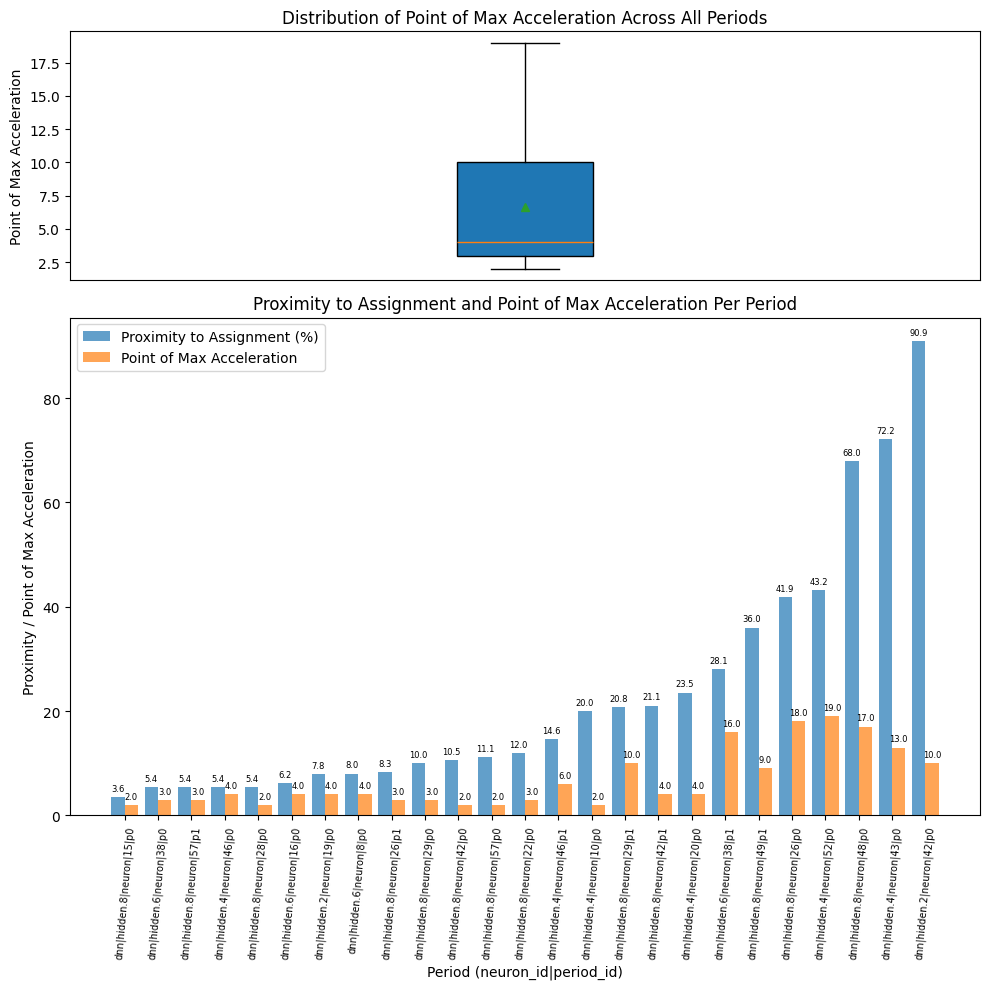

In [25]:
plot_all_points_of_max_acceleration(points_of_max_acceleration)

In [26]:
BTSP_START_STRATEGY = "acceleration"  # or "trial_start"


## 1.2 Filter periods

We have the choice to be "strict" with regards to the kept periods in a sense that a BTSP event should technically only occur iff the neuron is completely dead at the start of the trial. This would, however, remove most such periods.

In [27]:
recovery_periods = filter_periods(recovery_periods, df_dead, strict=STRICT)
display(recovery_periods.head(30))


Keeping recovery periods that are not dead at some point during that trial where the recovery occurs. 
 Would've removed 19/25 period(s) otherwise.


,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126
5,dnn|hidden.4|neuron|46,hidden.4,0,1085,1234.0,1074,1221,147
6,dnn|hidden.4|neuron|46,hidden.4,1,2567,NaN,2541,3000,459
7,dnn|hidden.4|neuron|52,hidden.4,0,1560,1630.0,1544,1613,69
8,dnn|hidden.6|neuron|16,hidden.6,0,1277,1319.0,1264,1305,41
9,dnn|hidden.6|neuron|38,hidden.6,0,1067,1222.0,1056,1209,153


## 2. Gather period information

We've now identified candidate BTSP events. We must gather some information in order to better characterize them.

### 2.1 One-Shot-ness

In [28]:
point_of_max_acceleration(nts,recovery_periods,"dnn|hidden.8|neuron|29",1)

10

In [29]:
period_angles = get_period_angles(
	nts,
	recovery_periods,
	from_point=BTSP_START_STRATEGY,
	use_real_progression=USE_REAL_PROGRESSION,
)
period_angles.head(20)


activation_angle
neuron_id              period_id                  
dnn|hidden.2|neuron|19 0                  2.280570
dnn|hidden.2|neuron|42 0                  0.491616
dnn|hidden.4|neuron|10 0                  0.033716
dnn|hidden.4|neuron|20 0                  6.906849
dnn|hidden.4|neuron|43 0                  0.969324
dnn|hidden.4|neuron|46 0                  3.098275
                       1                  1.842651
dnn|hidden.4|neuron|52 0                  2.362023
dnn|hidden.6|neuron|16 0                  2.588796
dnn|hidden.6|neuron|38 0                  0.799152
                       1                  0.893810
dnn|hidden.6|neuron|8  0                  0.449996
dnn|hidden.8|neuron|15 0                  1.373213
dnn|hidden.8|neuron|22 0                  2.048089
dnn|hidden.8|neuron|26 0                  0.496531
                       1                  1.592454
dnn|hidden.8|neuron|28 0                  1.798790
dnn|hidden.8|neuron|29 0                  0.429780
                       1                  3.116625
dnn|hidden.8|neuron|42 0                  1.585296

In [30]:
def show_activations_of_trial(nts,recovery_periods,neuron_id: str,period_id: int | None = None):
	trial_start_iter, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
	activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id,surrounding_n_trials=(1,0))

	
	x_full = np.arange(len(activations)).astype(np.float64)
	x_deriv = x_full[:-1] + 0.5  
	x_2nd_deriv = x_full[:-2] + 1.0
	
	derivative = np.diff(activations.astype(np.float64), axis=0)  # Shape (99, 50)
	second_derivative = np.diff(derivative, axis=0)  # Shape (98, 50)
	
	true_iterations = trial_start_iter - N_SAMPLES_PER_TRIAL + x_full
	dx_iter = np.diff(true_iterations.astype(np.float64))
	angle_deg = np.degrees(np.arctan2(derivative, dx_iter[:, np.newaxis]))  # signed slope; matches mpl_neuron_eval_activation_angle_over_time
	
	vline_x = delta + N_SAMPLES_PER_TRIAL
	
	# Create figure with GridSpec
	n_rows, n_cols = 5, 2
	n_plots_per_digit = 4
	fig = plt.figure(figsize=(20, 24))
	gs = GridSpec(
		n_rows * n_plots_per_digit,
		n_cols,
		figure=fig,
	)
	
	# Plot for each digit
	for d in range(_NETWORK_N_DIGITS):
		row_idx = d // n_cols
		col_idx = d % n_cols
		
		# Extract activations for this digit (K=5 samples)
		start_col = d * _NETWORK_SAMPLES_PER_DIGIT
		end_col = start_col + _NETWORK_SAMPLES_PER_DIGIT
		digit_act = activations[:, start_col:end_col]
		digit_deriv = derivative[:, start_col:end_col]
		digit_angle = angle_deg[:, start_col:end_col]
		digit_2nd_deriv = second_derivative[:, start_col:end_col]
		
		# Create four subplots for this digit (stacked vertically)
		ax_act = fig.add_subplot(gs[row_idx * 4, col_idx])
		ax_deriv = fig.add_subplot(gs[row_idx * 4 + 1, col_idx])
		ax_angle = fig.add_subplot(gs[row_idx * 4 + 2, col_idx])
		ax_2nd_deriv = fig.add_subplot(gs[row_idx * 4 + 3, col_idx])
		
		# Plot traces for each of K=5 samples
		for k in range(_NETWORK_SAMPLES_PER_DIGIT):
			color = _NETWORK_EVAL_K_LINE_COLORS[k % len(_NETWORK_EVAL_K_LINE_COLORS)]
			label = f"K={k + 1}"
			
			# Activation
			ax_act.plot(
				x_full,
				digit_act[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Derivative
			ax_deriv.plot(
				x_deriv,
				digit_deriv[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Signed angle atan2(da, diter) per segment (same convention as mpl_neuron_eval_activation_angle_over_time)
			ax_angle.plot(
				x_full[1:],
				digit_angle[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Second derivative
			ax_2nd_deriv.plot(
				x_2nd_deriv,
				digit_2nd_deriv[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
		
		# Add vertical dashed line at delta for all four subplots
		for ax in [ax_act, ax_deriv, ax_angle, ax_2nd_deriv]:
			ax.axvline(vline_x, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1)
			ax.axhline(0.0, color=C["border"], linewidth=0.8, linestyle="-", zorder=0)
			ax.grid(True, color=C["grid"], linestyle="-", linewidth=0.8, alpha=0.6)
			ax.set_facecolor("white")
			for spine in ax.spines.values():
				spine.set_color(C["border"])
			ax.tick_params(colors=C["fg"], labelsize=8)
		
		# Titles for activation subplot (top of each digit column)
		ax_act.set_title(f"Digit {d}", fontsize=11, color=C["fg"], pad=12, fontweight="bold")
		
		# Y-axis labels
		ax_act.set_ylabel("Activation", fontsize=9, color=C["fg"])
		ax_act.set_facecolor("#f0f0f0")
		ax_act.axhline(0.0, color=C["red"], linewidth=0.8, linestyle="-", zorder=0)
		ax_deriv.set_ylabel("dA/dt", fontsize=9, color=C["fg"])
		ax_angle.set_ylabel("Signed angle (°)", fontsize=9, color=C["fg"])
		ax_angle.set_ylim(-10,10)
		ax_2nd_deriv.set_ylabel("d²A/dt²", fontsize=9, color=C["fg"])
		
		# X-axis labels (only for bottom row) - set to true iteration values
		# if row_idx == n_rows - 1:
		# Set x-ticks and labels to true iterations
		tick_indices = np.linspace(0, len(activations) - 1, 5, dtype=int)
		tick_labels = [str(int(true_iterations[i])) for i in tick_indices]
		def set_tick_labels(ax,tick_indices,tick_labels):
			ax.set_xticks(tick_indices)
			ax.set_xticklabels(tick_labels, fontsize=8)
		set_tick_labels(ax_2nd_deriv,tick_indices,tick_labels)
		set_tick_labels(ax_deriv,tick_indices,tick_labels)
		set_tick_labels(ax_angle,tick_indices,tick_labels)
		set_tick_labels(ax_act,tick_indices,tick_labels)
		ax_2nd_deriv.set_xlabel("Iteration", fontsize=9, color=C["fg"])
		
		# Remove x-tick labels for non-bottom rows
		# if row_idx < n_rows - 1:
		# 	ax_act.set_xticklabels([])
		# 	ax_deriv.set_xticklabels([])
		# 	ax_angle.set_xticklabels([])
		# 	ax_2nd_deriv.set_xticklabels([])
		
		# Legend only on first digit
		if d == 0:
			ax_act.legend(
				loc="upper right",
				fontsize=8,
				framealpha=0.92,
				edgecolor=C["border"],
				ncol=1,
			)
	start_iter,_,_ = get_trial_starts(recovery_periods,neuron_id,period_id)
	fig.suptitle(
		f"Activation Analysis: {_compact_neuron_label(neuron_id)} (Trial from iter {start_iter})",
		fontsize=13,
		color=C["fg"],
		fontweight="bold",
	)
	fig.patch.set_facecolor("white")
	
	fig.tight_layout()
	
	return fig

In [31]:
PLOT = False
if PLOT:
	show_activations_of_trial(nts,recovery_periods,neuron_id="dnn|hidden.4|neuron|20",period_id=0)

f(2)=0.022, f(10)=0.500, f(90)=1.000


/tmp/ipykernel_398874/83636241.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


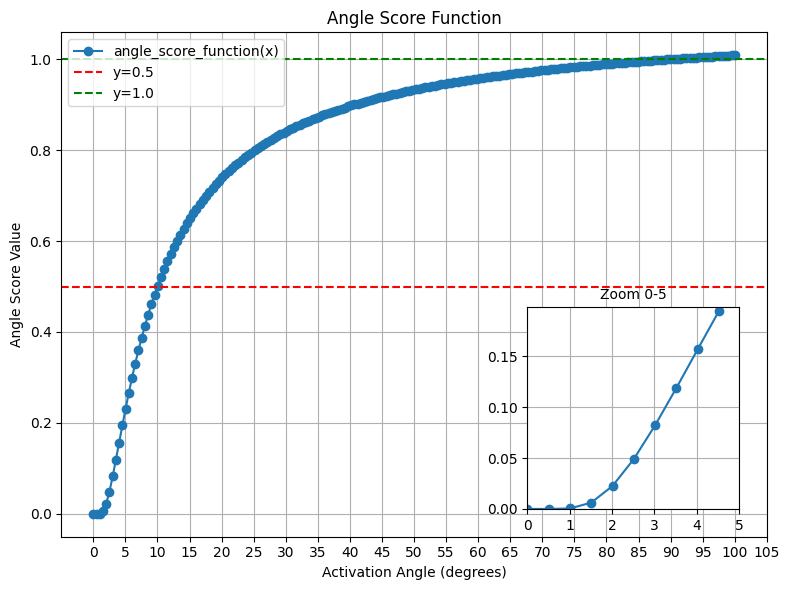

<Figure size 640x480 with 0 Axes>

In [32]:
print(f"f(2)={angle_score_function(2):.3f}, f(10)={angle_score_function(10):.3f}, f(90)={angle_score_function(90):.3f}")

x = np.linspace(0.001, 100, 200)
y = np.array([angle_score_function(xi) for xi in x])

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, y, marker="o", label="angle_score_function(x)")
ax.axhline(0.5, color="red", linestyle="--", label="y=0.5")
ax.axhline(1.0, color="green", linestyle="--", label="y=1.0")
ax.set_xlabel("Activation Angle (degrees)")
ax.set_ylabel("Angle Score Value")
ax.set_title("Angle Score Function")
ax.legend(loc="upper left")
ax.grid(True)
ax.set_xticks(np.arange(0, 110, 5))

axins = inset_axes(ax, width="30%", height="40%", loc="lower right", borderpad=2)
axins.plot(x, y, marker="o")
axins.axhline(0.5, color="red", linestyle="--")
axins.axhline(1.0, color="green", linestyle="--")
x_zoom_idx = (x >= 0) & (x <= 5)
y_zoom = y[x_zoom_idx]
axins.set_xlim(0, 5)
axins.set_ylim(min(y_zoom) * 0.98, max(y_zoom) * 1.02)
axins.set_xticks(np.arange(0, 6, 1))
axins.set_title("Zoom 0-5", fontsize=10)
axins.grid(True)
plt.tight_layout()
plt.show()
plt.savefig(PLOTS_DIR/"angle_score_function.pdf")


In [33]:
angles_scores = period_angles.assign(
	angle_score=lambda df: df["activation_angle"].map(angle_score_function)
).drop(columns={"activation_angle"})
angles_scores.head(20)


angle_score
neuron_id              period_id               
dnn|hidden.2|neuron|19 0           3.569890e-02
dnn|hidden.2|neuron|42 0           1.409127e-07
dnn|hidden.4|neuron|10 0          3.924074e-101
dnn|hidden.4|neuron|20 0           3.526190e-01
dnn|hidden.4|neuron|43 0           3.498383e-04
dnn|hidden.4|neuron|46 0           8.801830e-02
                       1           1.583944e-02
dnn|hidden.4|neuron|52 0           4.016639e-02
dnn|hidden.6|neuron|16 0           5.363619e-02
dnn|hidden.6|neuron|38 0           6.308138e-05
                       1           1.772940e-04
dnn|hidden.6|neuron|8  0           3.249477e-08
dnn|hidden.8|neuron|15 0           3.727788e-03
dnn|hidden.8|neuron|22 0           2.421552e-02
dnn|hidden.8|neuron|26 0           1.648685e-07
                       1           8.146696e-03
dnn|hidden.8|neuron|28 0           1.428649e-02
dnn|hidden.8|neuron|29 0           1.438176e-08
                       1           8.933232e-02
dnn|hidden.8|neuron|42 0           7.968557e-03

### 2.2 Activation sustainment

In [34]:
recovery_periods.head(20)

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126
5,dnn|hidden.4|neuron|46,hidden.4,0,1085,1234.0,1074,1221,147
6,dnn|hidden.4|neuron|46,hidden.4,1,2567,NaN,2541,3000,459
7,dnn|hidden.4|neuron|52,hidden.4,0,1560,1630.0,1544,1613,69
8,dnn|hidden.6|neuron|16,hidden.6,0,1277,1319.0,1264,1305,41
9,dnn|hidden.6|neuron|38,hidden.6,0,1067,1222.0,1056,1209,153


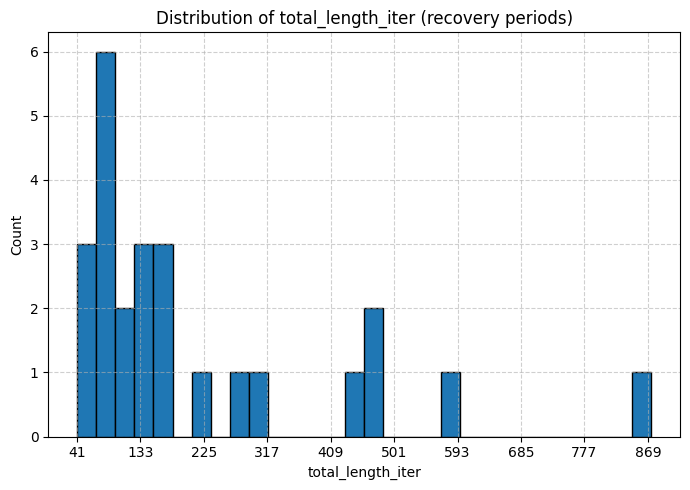

In [35]:
def plot_total_length_iter_distribution(df_periods):
	plt.figure(figsize=(7, 5))
	plt.hist(df_periods["total_length_iter"], bins=30, edgecolor="black")
	plt.xlabel("total_length_iter")
	plt.ylabel("Count")
	plt.title("Distribution of total_length_iter (recovery periods)")
	plt.grid(True, linestyle="--", alpha=0.6)
	ax = plt.gca()
	data = df_periods["total_length_iter"]
	xmin, xmax = data.min(), data.max()
	n_ticks = 10 
	tick_step = max(1, int((xmax - xmin) / (n_ticks - 1)))
	ticks = list(range(int(xmin), int(xmax) + 1, tick_step))
	ax.set_xticks(ticks)

	plt.tight_layout()
	plt.show()

plot_total_length_iter_distribution(recovery_periods)

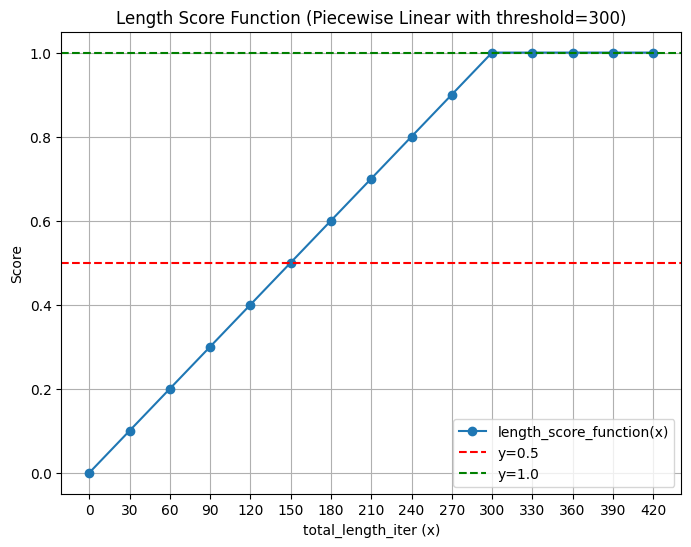

In [36]:
def plot_length_function():
	threshold = 3 * N_SAMPLES_PER_TRIAL
	x_int = np.arange(0, threshold + 5 * (threshold // 10), step=threshold // 10)
	y_length = np.array([length_score_function(xi) for xi in x_int])

	plt.figure(figsize=(8, 6))
	plt.plot(x_int, y_length, marker="o", label="length_score_function(x)")
	plt.axhline(0.5, color="red", linestyle="--", label="y=0.5")
	plt.axhline(1.0, color="green", linestyle="--", label="y=1.0")
	plt.xlabel("total_length_iter (x)")
	plt.ylabel("Score")
	plt.title(f"Length Score Function (Piecewise Linear with threshold={threshold})")
	plt.legend()
	plt.grid(True)
	plt.xticks(x_int)
	plt.show()


plot_length_function()


In [37]:
length_scores = (
	recovery_periods[index_grp + ["total_length_iter"]]
	.assign(length_score=lambda df: df["total_length_iter"].map(length_score_function))
	.drop(columns={"total_length_iter"})
	.set_index(index_grp)
)
length_scores.head(20)


length_score
neuron_id              period_id              
dnn|hidden.2|neuron|19 0              1.000000
dnn|hidden.2|neuron|42 0              0.740000
dnn|hidden.4|neuron|10 0              0.346667
dnn|hidden.4|neuron|20 0              0.346667
dnn|hidden.4|neuron|43 0              0.420000
dnn|hidden.4|neuron|46 0              0.490000
                       1              1.000000
dnn|hidden.4|neuron|52 0              0.230000
dnn|hidden.6|neuron|16 0              0.136667
dnn|hidden.6|neuron|38 0              0.510000
                       1              1.000000
dnn|hidden.6|neuron|8  0              0.576667
dnn|hidden.8|neuron|15 0              0.180000
dnn|hidden.8|neuron|22 0              1.000000
dnn|hidden.8|neuron|26 0              0.553333
                       1              0.266667
dnn|hidden.8|neuron|28 0              0.933333
dnn|hidden.8|neuron|29 0              0.296667
                       1              0.506667
dnn|hidden.8|neuron|42 0              0.286667

### 2.3 Feature uniqueness

In [38]:
assignments = get_assignments(df_nd, recovery_periods)
display(assignments.head(20))


n_assigned_at_start  n_partial_at_start  \
neuron_id              period_id                                            
dnn|hidden.2|neuron|19 0                            1                   1   
dnn|hidden.2|neuron|42 0                            1                   2   
dnn|hidden.4|neuron|10 0                            1                   2   
dnn|hidden.4|neuron|20 0                            1                   1   
dnn|hidden.4|neuron|43 0                            1                   1   
dnn|hidden.4|neuron|46 0                            1                   2   
                       1                            1                   3   
dnn|hidden.4|neuron|52 0                            1                   2   
dnn|hidden.6|neuron|16 0                            1                   1   
dnn|hidden.6|neuron|38 0                            1                   1   
                       1                            1                   0   
dnn|hidden.6|neuron|8  0                            1                   5   
dnn|hidden.8|neuron|15 0                            1                   0   
dnn|hidden.8|neuron|22 0                            1                   3   
dnn|hidden.8|neuron|26 0                            1                   1   
                       1                            1                   4   
dnn|hidden.8|neuron|28 0                            1                   3   
dnn|hidden.8|neuron|29 0                            1                   2   
                       1                            1                   3   
dnn|hidden.8|neuron|42 0                            1                   2   

                                  n_assigned_digits_unique  \
neuron_id              period_id                             
dnn|hidden.2|neuron|19 0                                 1   
dnn|hidden.2|neuron|42 0                                 1   
dnn|hidden.4|neuron|10 0                                 1   
dnn|hidden.4|neuron|20 0                                 1   
dnn|hidden.4|neuron|43 0                                 1   
dnn|hidden.4|neuron|46 0                                 1   
                       1                                 2   
dnn|hidden.4|neuron|52 0                                 1   
dnn|hidden.6|neuron|16 0                                 1   
dnn|hidden.6|neuron|38 0                                 1   
                       1                                 1   
dnn|hidden.6|neuron|8  0                                 3   
dnn|hidden.8|neuron|15 0                                 1   
dnn|hidden.8|neuron|22 0                                 3   
dnn|hidden.8|neuron|26 0                                 1   
                       1                                 3   
dnn|hidden.8|neuron|28 0                                 5   
dnn|hidden.8|neuron|29 0                                 1   
                       1                                 2   
dnn|hidden.8|neuron|42 0                                 1   

                                  n_partial_digits_unique  
neuron_id              period_id                           
dnn|hidden.2|neuron|19 0                                5  
dnn|hidden.2|neuron|42 0                                5  
dnn|hidden.4|neuron|10 0                                3  
dnn|hidden.4|neuron|20 0                                5  
dnn|hidden.4|neuron|43 0                                3  
dnn|hidden.4|neuron|46 0                                9  
                       1                                9  
dnn|hidden.4|neuron|52 0                                2  
dnn|hidden.6|neuron|16 0                                1  
dnn|hidden.6|neuron|38 0                                3  
                       1                                3  
dnn|hidden.6|neuron|8  0                                6  
dnn|hidden.8|neuron|15 0                                0  
dnn|hidden.8|neuron|22 0                                7  
dnn|hidden.8|n

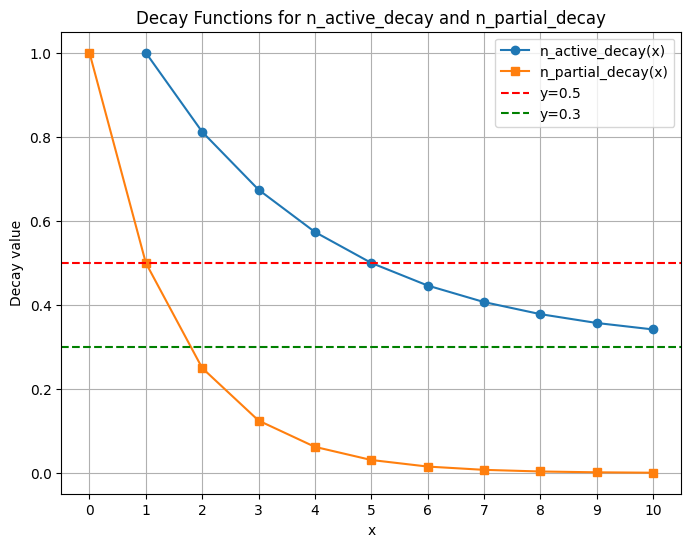

In [39]:
# Decay functions are imported from scoring_helpers; this cell only visualizes them.
x_int = np.arange(0, 11)
y_active = np.array([n_active_decay(xi) if xi != 0 else np.nan for xi in x_int])
y_partial = np.array([n_partial_decay(xi) for xi in x_int])

plt.figure(figsize=(8, 6))
plt.plot(x_int, y_active, marker="o", label="n_active_decay(x)")
plt.plot(x_int, y_partial, marker="s", label="n_partial_decay(x)")
plt.axhline(0.5, color="red", linestyle="--", label="y=0.5")
plt.axhline(0.3, color="green", linestyle="--", label="y=0.3")
plt.xlabel("x")
plt.ylabel("Decay value")
plt.title("Decay Functions for n_active_decay and n_partial_decay")
plt.legend()
plt.grid(True)
plt.xticks(x_int)
plt.show()


In [40]:
n_partial_decay(1)

np.float64(0.5)

In [41]:
n_active_decay(5)

np.float64(0.5)

In [42]:
assignment_scores = assignments.groupby(index_grp, sort=False).apply(
	lambda df: pd.Series(
		{
			"n_partial_decay_score": n_partial_decay(int(df["n_partial_at_start"].iloc[0])),
			"n_active_decay_score": n_active_decay(int(df["n_assigned_at_start"].iloc[0])),
		}
	)
)
assignment_scores.head(25)


n_partial_decay_score  n_active_decay_score
neuron_id              period_id                                             
dnn|hidden.2|neuron|19 0                        0.50000                   1.0
dnn|hidden.2|neuron|42 0                        0.25000                   1.0
dnn|hidden.4|neuron|10 0                        0.25000                   1.0
dnn|hidden.4|neuron|20 0                        0.50000                   1.0
dnn|hidden.4|neuron|43 0                        0.50000                   1.0
dnn|hidden.4|neuron|46 0                        0.25000                   1.0
                       1                        0.12500                   1.0
dnn|hidden.4|neuron|52 0                        0.25000                   1.0
dnn|hidden.6|neuron|16 0                        0.50000                   1.0
dnn|hidden.6|neuron|38 0                        0.50000                   1.0
                       1                        1.00000                   1.0
dnn|hidden.6|neuron|8  0                        0.03125                   1.0
dnn|hidden.8|neuron|15 0                        1.00000                   1.0
dnn|hidden.8|neuron|22 0                        0.12500                   1.0
dnn|hidden.8|neuron|26 0                        0.50000                   1.0
                       1                        0.06250                   1.0
dnn|hidden.8|neuron|28 0                        0.12500                   1.0
dnn|hidden.8|neuron|29 0                        0.25000                   1.0
                       1                        0.12500                   1.0
dnn|hidden.8|neuron|42 0                        0.25000                   1.0
                       1                        0.50000                   1.0
dnn|hidden.8|neuron|48 0                        0.50000                   1.0
dnn|hidden.8|neuron|49 1                        0.25000                   1.0
dnn|hidden.8|neuron|57 0                        0.03125                   1.0
                       1                        0.06250                   1.0

### 2.4 Representational distance to perfect model

RDX or SSIM

In [43]:
COMPUTATION_POINT = "max_activity"  # or "assignment_point"
EXPERT_MODEL_DIR = "local/save/expert_optimizer_pretrained/!OPT/"
PLOT = False


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DummyExp(MNISTWrapper):
	def experiment_id(self):
		return ""

	def _build_trials(self, batch_size: int, seed: int, *, num_experiment_runs: int):
		return []


eval_digits = DummyExp().evaluation_inputs(device)[0]
print(f"Using device: {device}")


Using device: cuda


In [45]:
from visualize_webapp.notebook.gbp_helper import plot_gradient_heatmaps


In [46]:
# find_target_checkpoint is imported from scoring_helpers.


In [47]:
prebuilt_pyramids: dict = {}
_, prebuilt_pyramids = init_cw_ssim_pyramid(device, prebuilt_pyramids)

saliency_checkpoint_cache: dict[int, torch.Tensor] = {}
period_saliency_maps: dict = {}

for row in tqdm(list(recovery_periods.itertuples()), desc="Computing saliency maps"):
	nid, pid = row.neuron_id, row.period_id
	target_cp = find_target_checkpoint(nid, pid, nts, recovery_periods, COMPUTATION_POINT)
	if target_cp not in saliency_checkpoint_cache:
		saliency_checkpoint_cache[target_cp] = get_all_saliency_maps(
			nts,
			checkpoint_idx=target_cp,
			device=device,
		)
	period_saliency_maps[(nid, pid)] = get_neuron_saliency_maps_from_all(
		saliency_checkpoint_cache[target_cp],
		nid,
	)


Computing saliency maps:   0%|          | 0/25 [00:00<?, ?it/s]

In [48]:
nts["weights__dnn|hidden.0|neuron|0"].shape, nts["act__dnn|hidden.0|neuron|0"].shape, nts["weights__dnn|hidden.2|neuron|0"].shape, nts["act__dnn|hidden.2|neuron|0"].shape

((3031, 784), (3031, 50), (3031, 64), (3031, 50))

In [49]:
# Custom saliency functions are imported from scoring_helpers.


In [50]:
def get_neuron_sample_custom_saliency_maps(nts, neuron_id, checkpoint_idx=0, convolve_=False):
	"""Compatibility wrapper for the original plotting cells; saliency computation lives in scoring_helpers."""
	all_saliency_maps = get_all_saliency_maps(
		nts,
		checkpoint_idx=checkpoint_idx,
		device=device,
		convolve_=convolve_,
	)
	return torch.stack(get_neuron_saliency_maps_from_all(all_saliency_maps, neuron_id.strip()))


$n^{(2)}_{20}$


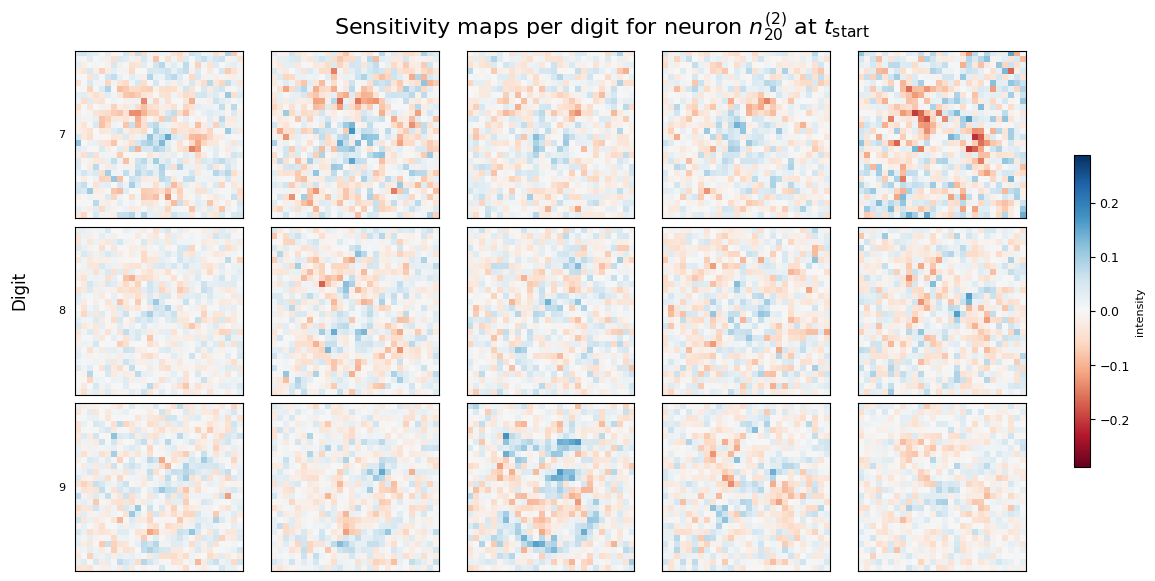

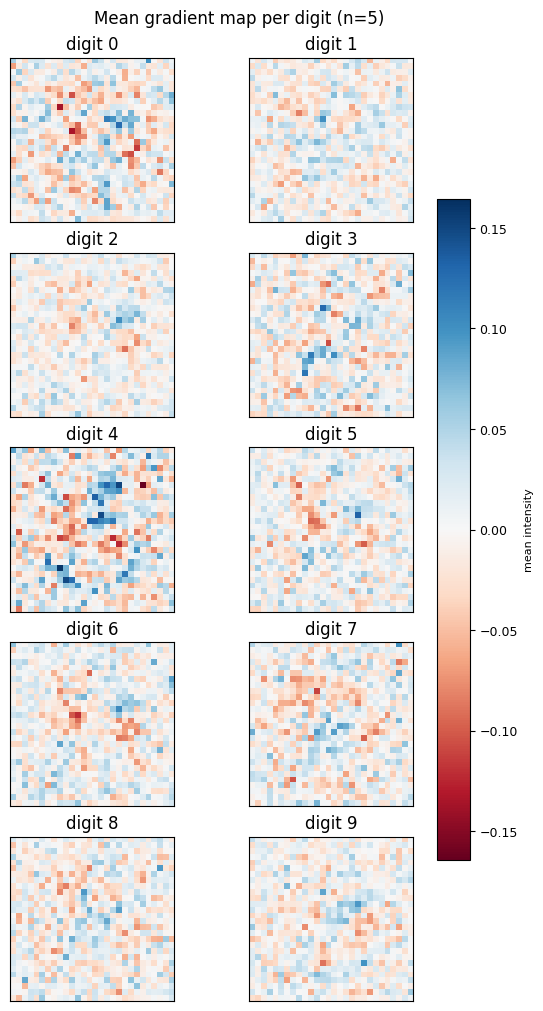

In [ ]:
nid = "dnn|hidden.4|neuron|20"
only_digits =  [7,8,9] # None
(f,_),_ = plot_gradient_heatmaps(get_neuron_sample_custom_saliency_maps(nts, nid).cpu().numpy(),neuron_id=nid, only_digits = only_digits)
# f.savefig(f"local/save/plots/{'full' if only_digits is None else 'few'}_recover_grafted_n220_sens_maps.pdf")
#  _,_ = plot_gradient_heatmaps(get_neuron_sample_custom_saliency_maps(nts, "dnn|hidden.4|neuron|51	",convolve_=True).cpu().numpy())


In [69]:
recovery_periods[recovery_periods["neuron_id"]==nid]

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104


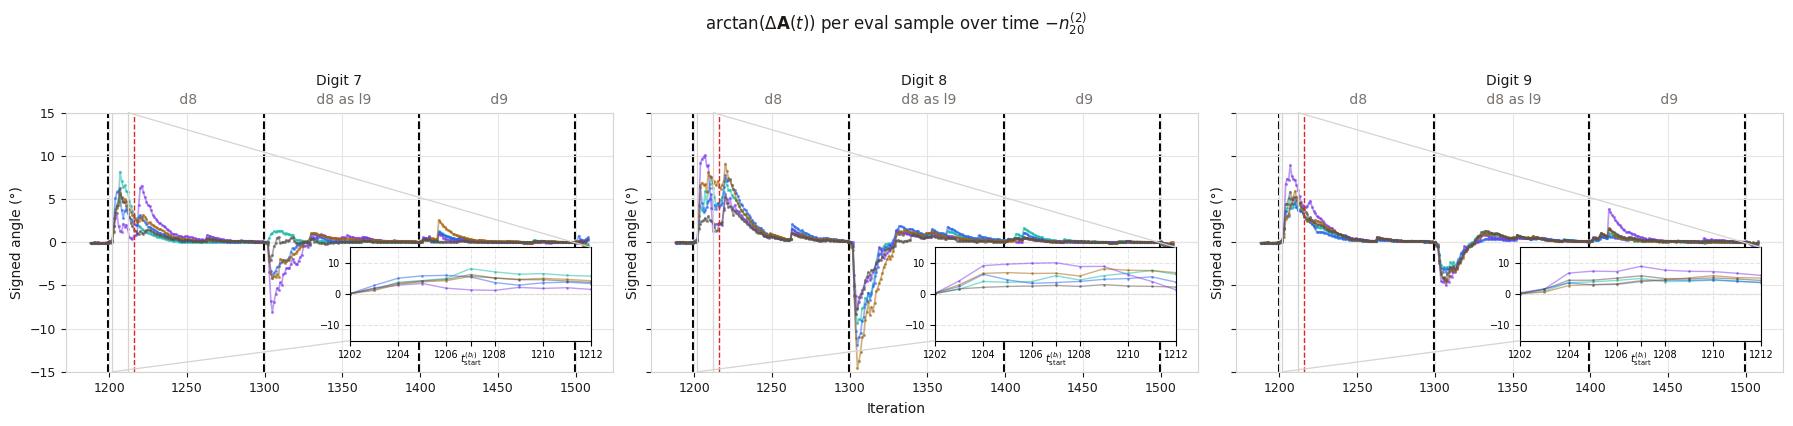

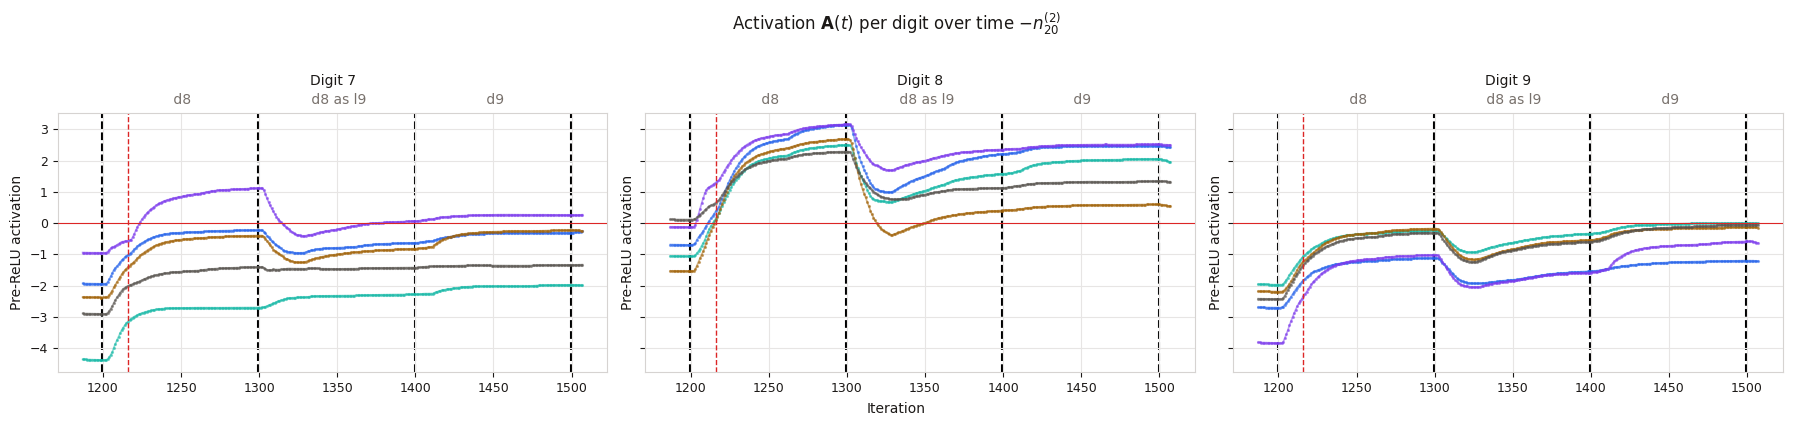

In [ ]:
MAX_ANGLE = 15
f = mpl_neuron_eval_activation_angle_over_time(nid, nts, metrics,signed_angle_y_deg_limit=MAX_ANGLE, min_idx = 1200, max_idx=1525,cp=1216,report = True, only_digits=only_digits, inset_center=1207)
f.savefig(f"local/save/plots/{'full' if only_digits is None else 'few'}_recover_grafted_n220_angle_over_time.pdf")
f = mpl_neuron_eval_activation_per_sample_over_time(nid,nts,metrics,min_idx=1200,max_idx=1525,cp=1216, report = True, only_digits=only_digits)
f.savefig(f"local/save/plots/{'full' if only_digits is None else 'few'}_recover_grafted_n220_activation_over_time.pdf")

In [54]:
assert False

AssertionError: 

In [ ]:
if PLOT:
	for (nid, pid), maps in period_saliency_maps.items():
		if nid == "dnn|hidden.4|neuron|20":
			print(len(maps),maps[0].shape)
			(fig1, _), (fig2, _) = plot_gradient_heatmaps(maps)
			fig1.suptitle(f"{nid}  period={pid}", fontsize=10)
			plt.show()
			plt.close("all")


In [ ]:
expert_dir = PROJECT_ROOT / Path(EXPERT_MODEL_DIR.replace("!OPT", OPTIMIZER_ID.replace("grafted", "graft")))
report = json.loads((expert_dir / "report.json").read_text())
expert_model = get_model(report["model_class"], **report["model_config"]).to(device)

expert_model.load_state_dict(torch.load(expert_dir / "model.pt", map_location="cpu", weights_only=True))
expert_model.eval()
print(f"Loaded expert model from {expert_dir}")


Loaded expert model from /home/garvalov/thesis/plateau_optimizer/network_analyzer/local/save/expert_optimizer_pretrained/graft_shampoo_lr0.01


In [ ]:
all_expert_saliency_maps = get_all_model_saliency_maps(expert_model, eval_digits, device)
expert_saliency = {
	nid: get_neuron_saliency_maps_from_all(all_expert_saliency_maps, nid)
	for nid in tqdm(list(recovery_periods["neuron_id"].unique()), desc="Expert saliency maps")
}


Expert saliency maps:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
if PLOT:
	for nid, maps in expert_saliency.items():
		(fig1, _), (fig2, _) = plot_gradient_heatmaps(maps)
		fig1.suptitle(f"{nid}", fontsize=10)
		plt.show()
		plt.close("all")


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
print(
	f"USE_CW_SSIM={USE_CW_SSIM}, PYRAMID_LEVELS={PYRAMID_LEVELS}, "
	f"WAVELET_ORIENTATIONS={WAVELET_ORIENTATIONS}, MNIST_IMAGE_SHAPE={MNIST_IMAGE_SHAPE}"
)


USE_CW_SSIM=True, PYRAMID_LEVELS=3, WAVELET_ORIENTATIONS=8, MNIST_IMAGE_SHAPE=(28, 28)


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


### 2.4.1 "Naive" normalized distance

The first technique to compute the feature learnt by this neuron is the following:

1. Compute the the saliency maps of the neuron defined by the neuron's sensitivity to the image input at the time of TODO: crossing/BTSP? $\frac{\partial \ \text{act}_i(\text{image}_p)}{\partial \ \text{image}_p}$
2. Compute an expert model's saliency map for that neuron
3. Compute the (M)SSIM for all $K=5*N=10$ samples, sample by sample (comparing model's saliency on sample i to expert's on sample i -> not considering cross sample SSIMs), and average the SSIM by digit. This creates the `mean_of_mssim` value
4. Average the saliency map per digit (yielding the neuron's average sensitivity for that digit) for both the considered model and the expert. Then, compute the (M)SSIM for all $N=10$ digits, This creates the `MSSSIM_of_mean` value
5. Similarly, per layer, compute the mean-MSSIM and MSSIM-of-mean for all neurons in each layer which *are not* considered for the BTSP periods. 
6. Normalize the values obtained in 4. by those obtained in 6.

Intuitively, if we interpret the saliency map (sensitivity of that neuron to the input image) as a representation of the neuron's feature-embedding, computing the structural similarity between two saliency maps will tell us how close the two representations are. Since it is expected that our non-expert model would have quite a different representation than our competent expert, normalizing this representational distance by the mean (per-layer) would tell us whether the the BTSP event has helped (>1.0) or not (<1.0) bridge the gap in feature representation


In [ ]:
df_ssim = get_period_mssims(
	recovery_periods,
	period_saliency_maps,
	expert_saliency,
	prebuilt_pyramids=prebuilt_pyramids,
)
df_ssim.head()


Computing SSIM:   0%|          | 0/25 [00:00<?, ?it/s]

layer_name  mean_of_mssim  \
neuron_id              period_id digit                             
dnn|hidden.2|neuron|19 0         0       hidden.2       0.605452   
                                 1       hidden.2       0.699033   
                                 2       hidden.2       0.633925   
                                 3       hidden.2       0.706699   
                                 4       hidden.2       0.646203   

                                        MSSIM_of_mean  
neuron_id              period_id digit                 
dnn|hidden.2|neuron|19 0         0           0.575326  
                                 1           0.707444  
                                 2           0.642791  
                                 3           0.715697  
                                 4           0.626118

In [ ]:
display(df_ssim.groupby(index_grp).agg({"layer_name":"first","mean_of_mssim": "mean", "MSSIM_of_mean": "mean"}).head(30))


layer_name  mean_of_mssim  MSSIM_of_mean
neuron_id              period_id                                         
dnn|hidden.2|neuron|19 0           hidden.2       0.660114       0.658926
dnn|hidden.2|neuron|42 0           hidden.2       0.659183       0.664805
dnn|hidden.4|neuron|10 0           hidden.4       0.624871       0.629597
dnn|hidden.4|neuron|20 0           hidden.4       0.591696       0.577993
dnn|hidden.4|neuron|43 0           hidden.4       0.623484       0.611898
dnn|hidden.4|neuron|46 0           hidden.4       0.616710       0.601828
                       1           hidden.4       0.621000       0.609663
dnn|hidden.4|neuron|52 0           hidden.4       0.647226       0.652867
dnn|hidden.6|neuron|16 0           hidden.6       0.573836       0.554718
dnn|hidden.6|neuron|38 0           hidden.6       0.585630       0.563410
                       1           hidden.6       0.584017       0.572031
dnn|hidden.6|neuron|8  0           hidden.6       0.610175       0.617257
dnn|hidden.8|neuron|15 0           hidden.8       0.607786       0.612194
dnn|hidden.8|neuron|22 0           hidden.8       0.520702       0.521190
dnn|hidden.8|neuron|26 0           hidden.8       0.610374       0.612235
                       1           hidden.8       0.590010       0.589954
dnn|hidden.8|neuron|28 0           hidden.8       0.510967       0.502789
dnn|hidden.8|neuron|29 0           hidden.8       0.620151       0.620605
                       1           hidden.8       0.607539       0.600310
dnn|hidden.8|neuron|42 0           hidden.8       0.509637       0.477427
                       1           hidden.8       0.490302       0.463930
dnn|hidden.8|neuron|48 0           hidden.8       0.584127       0.588520
dnn|hidden.8|neuron|49 1           hidden.8       0.590412       0.590808
dnn|hidden.8|neuron|57 0           hidden.8       0.568430       0.542746
                       1           hidden.8       0.558997       0.539041

<Axes: title={'center': 'Distribution of mean_of_mssim and MSSIM_of_mean per layer'}, xlabel='Layer', ylabel='CW-SSIM Similarity'>

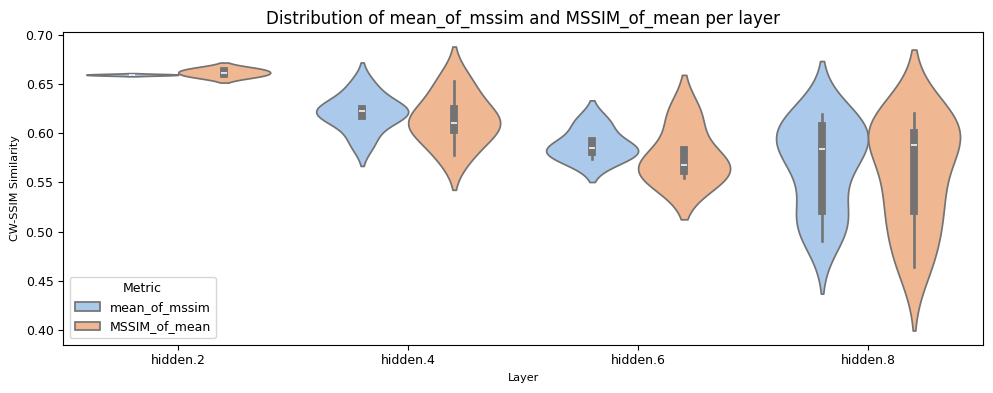

In [ ]:
def plot_side_by_side_similarities(similarities_df, ax=None):
	"""
	Plots violin plots of 'mean_of_mssim' and 'MSSIM_of_mean' side by side
	for each layer (each x tick has two violins).

	similarities_df: DataFrame with columns ["layer_name", "mean_of_mssim", "MSSIM_of_mean"]
	ax: matplotlib axis (optional)
	"""
	df = similarities_df.reset_index()

	# Melt into long format to plot both metrics side-by-side per layer
	df_long = pd.melt(
		df,
		id_vars=["layer_name"],
		value_vars=["mean_of_mssim", "MSSIM_of_mean"],
		var_name="metric",
		value_name="similarity"
	)

	if ax is None:
		plt.figure(figsize=(10, 4))
		ax = plt.gca()
	sns.violinplot(
		data=df_long,
		x="layer_name",
		y="similarity",
		hue="metric",
		inner="box",
		density_norm='width',  # replaces scale="width"
		ax=ax,
		palette="pastel",
		split=False,
		dodge=True
	)
	ax.set_title("Distribution of mean_of_mssim and MSSIM_of_mean per layer")
	ax.set_xlabel("Layer")
	ax.set_ylabel(f"{'CW-SSIM' if USE_CW_SSIM else 'MSSIM'} Similarity")
	ax.legend(title="Metric") 
	plt.tight_layout()
	return ax

plot_side_by_side_similarities(
	df_ssim.groupby(index_grp).agg({"layer_name":"first","mean_of_mssim": "mean", "MSSIM_of_mean": "mean"})
)

In [ ]:
df_layer_baseline = get_layer_baselines(
	nts,
	recovery_periods,
	eval_digits,
	device,
	expert_model,
	metrics=metrics,
	expert_saliency=expert_saliency,
	prebuilt_pyramids=prebuilt_pyramids,
)
display(df_layer_baseline)


Control saliency layer=hidden.2:   0%|          | 0/62 [00:00<?, ?it/s]

Control saliency layer=hidden.4:   0%|          | 0/59 [00:00<?, ?it/s]

Control saliency layer=hidden.6:   0%|          | 0/61 [00:00<?, ?it/s]

Control saliency layer=hidden.8:   0%|          | 0/55 [00:00<?, ?it/s]

mean_of_mssim  MSSIM_of_mean
layer_name digit                              
hidden.2   0           0.660388       0.665384
           1           0.656532       0.657672
           2           0.646728       0.642045
           3           0.655152       0.657111
           4           0.652850       0.654001
           5           0.653078       0.653663
           6           0.633726       0.623652
           7           0.652900       0.657862
           8           0.645611       0.643975
           9           0.654987       0.659921
hidden.4   0           0.636247       0.633474
           1           0.625675       0.630737
           2           0.620648       0.613862
           3           0.629111       0.632756
           4           0.627320       0.625034
           5           0.634820       0.639870
           6           0.594852       0.576607
           7           0.635056       0.628047
           8           0.607334       0.597131
           9           0.628800       0.631278
hidden.6   0           0.599628       0.591160
           1           0.618069       0.623567
           2           0.572116       0.546297
           3           0.616826       0.615904
           4           0.613038       0.609112
           5           0.614073       0.615945
           6           0.557045       0.529962
           7           0.618035       0.611832
           8           0.588356       0.576784
           9           0.603673       0.605903
hidden.8   0           0.566653       0.555801
           1           0.593487       0.596020
           2           0.532051       0.499649
           3           0.584355       0.586065
           4           0.610113       0.622469
           5           0.605383       0.605632
           6           0.524442       0.505659
           7           0.618687       0.620401
           8           0.573622       0.568462
           9           0.588227       0.604631

In [ ]:
normalized_period_ssims = get_normalize_ssims(df_ssim, df_layer_baseline)
display(normalized_period_ssims.head(60))


normalized_mean_of_mssim  \
neuron_id              period_id digit                             
dnn|hidden.2|neuron|19 0         0                      0.916812   
                                 1                      1.064736   
                                 2                      0.980204   
                                 3                      1.078680   
                                 4                      0.989818   
                                 5                      1.065841   
                                 6                      0.880316   
                                 7                      1.055956   
                                 8                      1.052624   
                                 9                      1.048644   
dnn|hidden.2|neuron|42 0         0                      0.986097   
                                 1                      1.041358   
                                 2                      1.018987   
                                 3                      1.017710   
                                 4                      1.017844   
                                 5                      0.965231   
                                 6                      1.040162   
                                 7                      1.016878   
                                 8                      1.011500   
                                 9                      1.007919   
dnn|hidden.4|neuron|10 0         0                      0.991122   
                                 1                      0.971666   
                                 2                      1.059730   
                                 3                      0.961429   
                                 4                      1.047383   
                                 5                      0.985294   
                                 6                      0.999633   
                                 7                      1.036680   
                                 8                      0.992782   
                                 9                      0.968729   
dnn|hidden.4|neuron|20 0         0                      0.950084   
                                 1                      0.868363   
                                 2                      0.900994   
                                 3                      0.994237   
                                 4                      1.000568   
                                 5                      0.966881   
                                 6                      0.835229   
                                 7                      1.004998   
                                 8                      0.935847   
                                 9                      1.017119   
dnn|hidden.4|neuron|43 0         0                      1.031200   
                                 1                      0.998458   
                                 2                      0.997864   
                                 3                      1.028875   
                                 4                      1.055920   
                                 5                      0.940918   
                                 6                      0.887409   
                                 7                      1.009134   
                                 8                      1.103590   
                                 9                      0.936282   
dnn|hidden.4|neuron|46 0         0                      1.004535   
                                 1                      1.035518   
                                 2                      1.010037   
                                 3                      1.042717   
                                 4                      0.981396   
                                 5                      0.974231   
                                 6                      1.070912   
                            

### 2.2  RDX-like optimization

(Kondapaneni et al., 2025)

See notes.
We have two options.

**NOTE** : MSSIM is not stucturally invariant \cite{Understanding SSIM}. We prefer CW-SSIM to compare cross digits

#### 2.2.1 Cross-samples distances

In the cross-sample case, we treat the "Saliency space" as an embedding space of the feature learnt by a neuron, assuming that this embedding space is shared accross all samples and digits (where a digit is a category).


##### 2.2.1.i Compute distance matrices. 

In this case, we want D_ij to contain the MSSIM of sample i to sample j for a given model : MSSIM(model_i,model_j). Note that this is different from 2.1 where we directly computed MSSIM(model_i,expert_i)

In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
cross_sample_distances_model_per_digit, cross_sample_distances_expert_per_digit = get_all_cross_sample_distances(
	recovery_periods,
	period_saliency_maps,
	expert_saliency,
	prebuilt_pyramids=prebuilt_pyramids,
)


Computing CW-SSIM:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
cross_sample_distances_model_cross_digit, cross_sample_distances_expert_cross_digit = get_all_cross_sample_distances(
	recovery_periods,
	period_saliency_maps,
	expert_saliency,
	cross_digit_grid=True,
	prebuilt_pyramids=prebuilt_pyramids,
)


Computing CW-SSIM:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
cross_sample_distances_model_per_digit.loc["dnn|hidden.8|neuron|42",0,0].values[0]

array([[1.00000405, 0.75616193, 0.63980377, 0.72378719, 0.68507326],
       [0.75616193, 1.00000548, 0.6678862 , 0.69994825, 0.70085132],
       [0.63980377, 0.6678862 , 1.00000143, 0.66582894, 0.57312834],
       [0.72378719, 0.69994825, 0.66582894, 1.00000274, 0.62730622],
       [0.68507326, 0.70085132, 0.57312834, 0.62730622, 1.00002038]])

In [ ]:
cross_sample_distances_model_cross_digit.loc["dnn|hidden.8|neuron|42",0].values[0][:8,:8]

array([[1.00000405, 0.75616193, 0.63980377, 0.72378719, 0.68507326,
        0.67142558, 0.52355623, 0.6545825 ],
       [0.75616193, 1.00000548, 0.6678862 , 0.69994825, 0.70085132,
        0.68608898, 0.53770453, 0.66556823],
       [0.63980377, 0.6678862 , 1.00000143, 0.66582894, 0.57312834,
        0.67128658, 0.61211574, 0.69238061],
       [0.72378719, 0.69994825, 0.66582894, 1.00000274, 0.62730622,
        0.67963189, 0.57280397, 0.68375152],
       [0.68507326, 0.70085132, 0.57312834, 0.62730622, 1.00002038,
        0.580374  , 0.41557103, 0.5875752 ],
       [0.67142558, 0.68608898, 0.67128658, 0.67963189, 0.580374  ,
        1.00000131, 0.61586255, 0.6907534 ],
       [0.52355623, 0.53770453, 0.61211574, 0.57280397, 0.41557103,
        0.61586255, 1.00000024, 0.66474319],
       [0.6545825 , 0.66556823, 0.69238061, 0.68375152, 0.5875752 ,
        0.6907534 , 0.66474319, 1.00000155]])

In [ ]:
s1,s2 = cross_sample_distances_model_cross_digit.loc["dnn|hidden.8|neuron|48",0].values[0],cross_sample_distances_expert_cross_digit.loc["dnn|hidden.8|neuron|48",0].values[0]

In [ ]:
d1,d2 = 1/s1, 1/s2

In [ ]:
G_se = compute_G(distance_to_rank(d1),distance_to_rank(d2))

idcs_of_interest = np.ix_(sample_ics_for_digits(get_assigned_digits_for_trial_activations(nts,recovery_periods,"dnn|hidden.8|neuron|48",0)),sample_ics_for_digits(get_assigned_digits_for_trial_activations(nts,recovery_periods,"dnn|hidden.8|neuron|48",0)))
rest_mask = np.ones(G_se.shape, dtype=bool)
rest_mask[idcs_of_interest] = False
G_se[idcs_of_interest].mean()/np.abs(G_se[rest_mask]).mean()

np.float64(-0.5217275032040939)

In [ ]:
# Helper implementation imported from analysis.scoring_helpers.


In [ ]:
recovery_periods.head()

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126


In [ ]:
merged_cross_digit_distances = cross_sample_distances_model_cross_digit.join(
	cross_sample_distances_expert_cross_digit,
	lsuffix="_model",
	rsuffix="_expert",
).reset_index()

representation_similarity_factors = recovery_periods.merge(merged_cross_digit_distances, on=index_grp).assign(
	representation_similarity_factor=lambda df: df.apply(
		lambda row: compute_repr_sim_factor(
			nts,
			row["neuron_id"],
			row["period_id"],
			row["cross_sample_distances_model"],
			row["cross_sample_distances_expert"],
			recovery_periods,
		),
		axis=1,
	)
)
representation_similarity_factors = representation_similarity_factors.drop(
	columns={c for c in representation_similarity_factors.columns if c not in index_grp + ["representation_similarity_factor"]}
).set_index(index_grp)
representation_similarity_factors.head(30)


representation_similarity_factor
neuron_id              period_id                                  
dnn|hidden.2|neuron|19 0                                 -0.058598
dnn|hidden.2|neuron|42 0                                  0.134926
dnn|hidden.4|neuron|10 0                                  0.243921
dnn|hidden.4|neuron|20 0                                 -0.124437
dnn|hidden.4|neuron|43 0                                 -0.200491
dnn|hidden.4|neuron|46 0                                  0.067624
                       1                                  0.063974
dnn|hidden.4|neuron|52 0                                  0.178509
dnn|hidden.6|neuron|16 0                                 -0.049268
dnn|hidden.6|neuron|38 0                                  0.153628
                       1                                 -0.150748
dnn|hidden.6|neuron|8  0                                 -0.147277
dnn|hidden.8|neuron|15 0                                 -0.070347
dnn|hidden.8|neuron|22 0                                 -0.236792
dnn|hidden.8|neuron|26 0                                 -0.279282
                       1                                 -0.429656
dnn|hidden.8|neuron|28 0                                 -0.289315
dnn|hidden.8|neuron|29 0                                 -0.259473
                       1                                  0.201518
dnn|hidden.8|neuron|42 0                                 -0.284300
                       1                                 -0.052150
dnn|hidden.8|neuron|48 0                                 -0.176317
dnn|hidden.8|neuron|49 1                                 -0.283407
dnn|hidden.8|neuron|57 0                                 -0.354203
                       1                                 -0.041576

In [ ]:
repr_similarity_score_function(-1.5)

np.float64(0.8999999999999999)

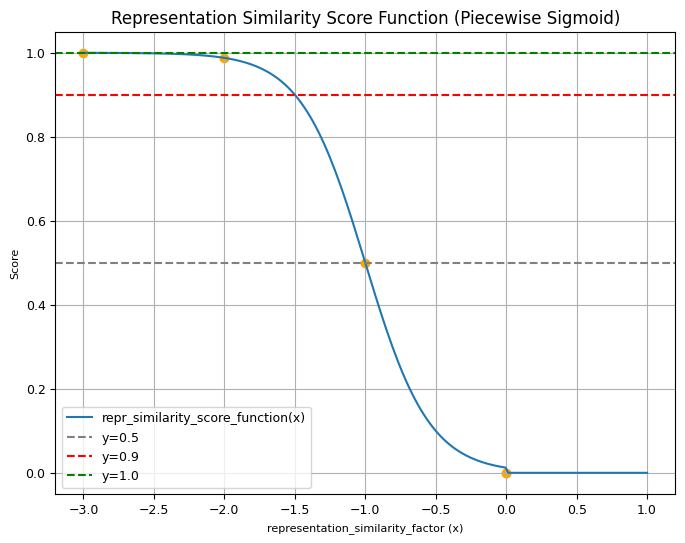

In [ ]:
def plot_repr_similarity_score_function():
	x_vals = np.linspace(-3, 1, 200)
	y_vals = [repr_similarity_score_function(x) for x in x_vals]
	x_int = np.concatenate([np.arange(-3, 1, 1), [0]])
	y_int = [repr_similarity_score_function(xi) for xi in x_int]

	plt.figure(figsize=(8, 6))
	plt.plot(x_vals, y_vals, label="repr_similarity_score_function(x)")
	plt.scatter(x_int, y_int, color="orange")
	plt.axhline(0.5, color="gray", linestyle="--", label="y=0.5")
	plt.axhline(0.9, color="red", linestyle="--", label="y=0.9")
	plt.axhline(1.0, color="green", linestyle="--", label="y=1.0")
	plt.xlabel("representation_similarity_factor (x)")
	plt.ylabel("Score")
	plt.title("Representation Similarity Score Function (Piecewise Sigmoid)")
	plt.legend()
	plt.grid(True)
	plt.show()


plot_repr_similarity_score_function()


In [ ]:
df_repr_similarity_scores = get_repr_similiraity_scores(representation_similarity_factors)
df_repr_similarity_scores.head(30)


repr_similarity_score
neuron_id              period_id                       
dnn|hidden.2|neuron|19 0                       0.015721
dnn|hidden.2|neuron|42 0                       0.000000
dnn|hidden.4|neuron|10 0                       0.000000
dnn|hidden.4|neuron|20 0                       0.020885
dnn|hidden.4|neuron|43 0                       0.028933
dnn|hidden.4|neuron|46 0                       0.000000
                       1                       0.000000
dnn|hidden.4|neuron|52 0                       0.000000
dnn|hidden.6|neuron|16 0                       0.015099
dnn|hidden.6|neuron|38 0                       0.000000
                       1                       0.023385
dnn|hidden.6|neuron|8  0                       0.023039
dnn|hidden.8|neuron|15 0                       0.016540
dnn|hidden.8|neuron|22 0                       0.033768
dnn|hidden.8|neuron|26 0                       0.040420
                       1                       0.075414
dnn|hidden.8|neuron|28 0                       0.042166
dnn|hidden.8|neuron|29 0                       0.037176
                       1                       0.000000
dnn|hidden.8|neuron|42 0                       0.041285
                       1                       0.015288
dnn|hidden.8|neuron|48 0                       0.026093
dnn|hidden.8|neuron|49 1                       0.041129
dnn|hidden.8|neuron|57 0                       0.055309
                       1                       0.014604

#### 2.2.2 Within-sample feature robustness [TODO later]

In the within-sample case, we treat consider the individual pixel sensitivities as embedding space; and compute cross-pixel distances within a sample. **Note**: since we use SSIM with a 5x5 kernel, we rather consider the pixel as kernel centers than indivdual pixels themselves. 

We will thus get per-sample differences of local representation between the model and the expert

### 2.3 Robustness through time

In [ ]:
STRIDE = 15

In [ ]:
period_checkpoint_df = get_period_checkpoint_indices(
	recovery_periods,
	stride = STRIDE,
	nts=nts,
	metrics=metrics,
	btsp_start_strategy=BTSP_START_STRATEGY,
)
(
	df_ssim_through_time,
	df_repr_similarity_factors_through_time,
	df_robustness_through_time,
) = get_period_scores_through_time(
	nts,
	recovery_periods,
	expert_saliency,
	device=device,
	metrics=metrics,
	prebuilt_pyramids=prebuilt_pyramids,
	checkpoint_df=period_checkpoint_df,
)

df_robustness_through_time_summary = summarize_through_time_metrics(df_robustness_through_time)
display(df_robustness_through_time.head())
display(df_robustness_through_time_summary.head())


Computing through-time metrics:   0%|          | 0/458 [00:00<?, ?it/s]

mean_of_mssim  mssim_of_mean  \
neuron_id              period_id checkpoint_idx                                 
dnn|hidden.2|neuron|19 0         1015                 0.677339       0.679154   
                                 1016                 0.676968       0.679052   
                                 1017                 0.675288       0.677000   
                                 1018                 0.674746       0.676441   
                                 1019                 0.674566       0.676370   

                                                layer_name  \
neuron_id              period_id checkpoint_idx              
dnn|hidden.2|neuron|19 0         1015             hidden.2   
                                 1016             hidden.2   
                                 1017             hidden.2   
                                 1018             hidden.2   
                                 1019             hidden.2   

                                                 representation_similarity_factor  \
neuron_id              period_id checkpoint_idx                                     
dnn|hidden.2|neuron|19 0         1015                                   -0.444298   
                                 1016                                   -0.440328   
                                 1017                                   -0.266391   
                                 1018                                   -0.266293   
                                 1019                                   -0.266889   

                                                 iteration  
neuron_id              period_id checkpoint_idx             
dnn|hidden.2|neuron|19 0         1015                 1004  
                                 1016                 1005  
                                 1017                 1006  
                                 1018                 1007  
                                 1019                 1008

,,TT_mean_of_mssim_mean,TT_mean_of_mssim_sem,TT_mssim_of_mean_mean,TT_mssim_of_mean_sem,TT_representation_similarity_factor_mean,TT_representation_similarity_factor_sem
neuron_id,period_id,,,,,,
dnn|hidden.2|neuron|19,0,0.665003,0.000638,0.664541,0.000786,-0.250389,0.016248
dnn|hidden.2|neuron|42,0,0.658810,0.000260,0.664732,0.000300,0.106446,0.003792
dnn|hidden.4|neuron|10,0,0.621034,0.000606,0.625926,0.000831,0.218633,0.010219
dnn|hidden.4|neuron|20,0,0.593839,0.001237,0.574417,0.001108,-0.133282,0.007077
dnn|hidden.4|neuron|43,0,0.623415,0.000305,0.607837,0.001234,-0.230409,0.018778


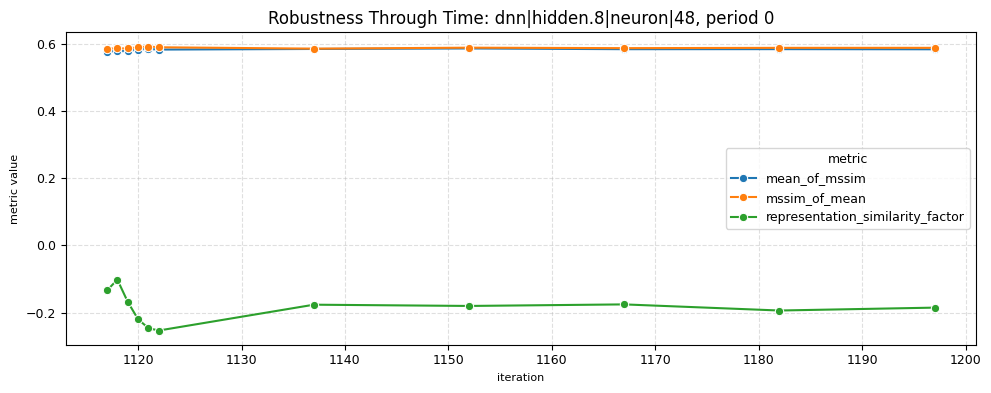

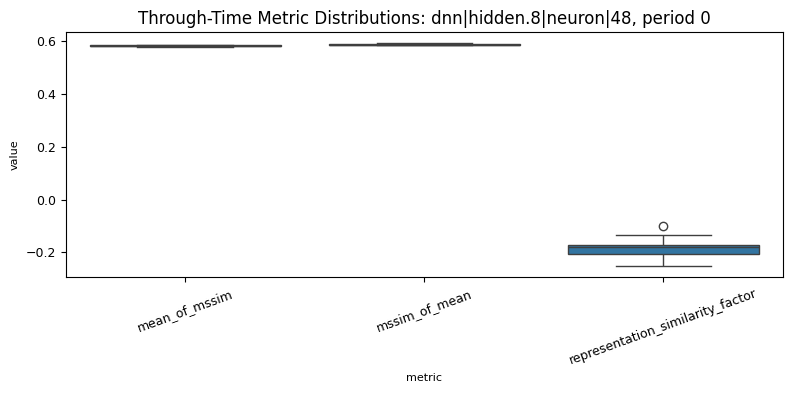

In [ ]:

TARGET_TT_NEURON_ID = "dnn|hidden.8|neuron|48"
TARGET_TT_PERIOD_ID = 0
TT_METRIC_COLUMNS = ["mean_of_mssim", "mssim_of_mean", "representation_similarity_factor"]

target_tt = df_robustness_through_time.reset_index()
target_tt = target_tt[
	(target_tt["neuron_id"] == TARGET_TT_NEURON_ID)
	& (target_tt["period_id"] == TARGET_TT_PERIOD_ID)
].sort_values("checkpoint_idx")

if target_tt.empty:
	print(f"No through-time robustness rows for {TARGET_TT_NEURON_ID}, period {TARGET_TT_PERIOD_ID}.")
else:
	x_col = "iteration" if "iteration" in target_tt.columns and target_tt["iteration"].notna().any() else "checkpoint_idx"
	target_tt_long = target_tt.melt(
		id_vars=["neuron_id", "period_id", "checkpoint_idx", x_col],
		value_vars=TT_METRIC_COLUMNS,
		var_name="metric",
		value_name="value",
	)

	fig, ax = plt.subplots(figsize=(10, 4))
	sns.lineplot(
		data=target_tt_long,
		x=x_col,
		y="value",
		hue="metric",
		marker="o",
		ax=ax,
	)
	ax.set_title(f"Robustness Through Time: {TARGET_TT_NEURON_ID}, period {TARGET_TT_PERIOD_ID}")
	ax.set_xlabel(x_col)
	ax.set_ylabel("metric value")
	ax.grid(True, linestyle="--", alpha=0.4)
	plt.tight_layout()
	plt.show()

	fig, ax = plt.subplots(figsize=(8, 4))
	sns.boxplot(
		data=target_tt_long,
		x="metric",
		y="value",
		ax=ax,
	)
	ax.set_title(f"Through-Time Metric Distributions: {TARGET_TT_NEURON_ID}, period {TARGET_TT_PERIOD_ID}")
	ax.set_xlabel("metric")
	ax.set_ylabel("value")
	ax.tick_params(axis="x", rotation=20)
	plt.tight_layout()
	plt.show()


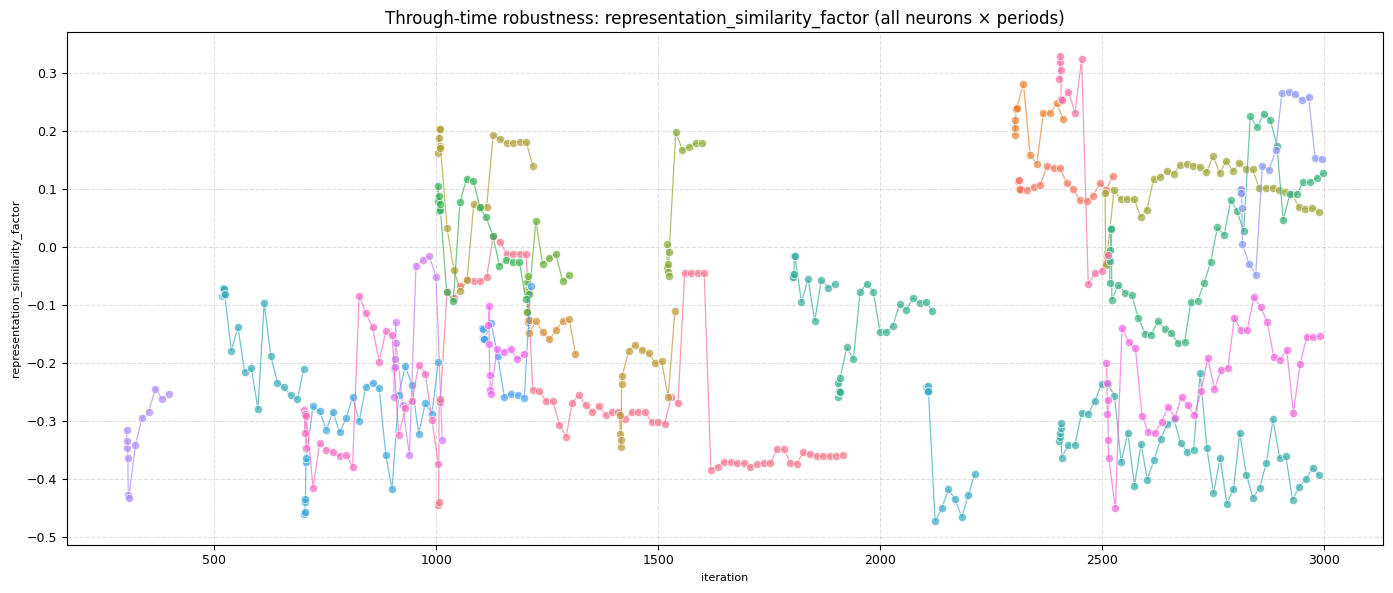

In [ ]:
tt = df_robustness_through_time.reset_index()

x_col = (
    "iteration"
    if "iteration" in tt.columns and tt["iteration"].notna().any()
    else "checkpoint_idx"
)

tt = tt.sort_values(["neuron_id", "period_id", x_col])

# One hue key per neuron × period (string is easiest for seaborn)
tt["trace_id"] = tt["neuron_id"].astype(str) + " | p" + tt["period_id"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=tt,
    x=x_col,
    y="representation_similarity_factor",
    hue="trace_id",
    estimator=None,   # one line per group; don't aggregate
    units="trace_id", # required with estimator=None in older seaborn
    marker="o",
    markers=True,
    dashes=False,
    linewidth=0.9,
    alpha=0.7,
    legend=False,     # legend will be huge; turn on only if few traces
    ax=ax,
)
ax.set_title("Through-time robustness: representation_similarity_factor (all neurons × periods)")
ax.set_xlabel(x_col)
ax.set_ylabel("representation_similarity_factor")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

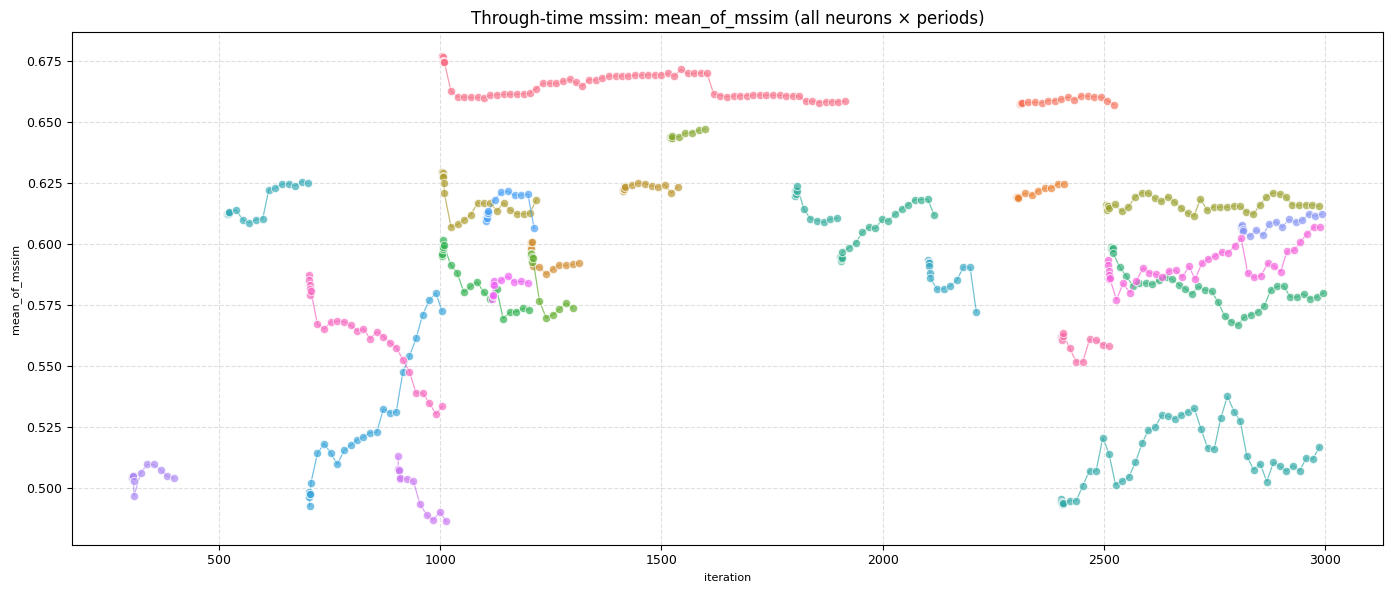

In [ ]:
tt = df_robustness_through_time.reset_index()

x_col = (
    "iteration"
    if "iteration" in tt.columns and tt["iteration"].notna().any()
    else "checkpoint_idx"
)

tt = tt.sort_values(["neuron_id", "period_id", x_col])

# One hue key per neuron × period (string is easiest for seaborn)
tt["trace_id"] = tt["neuron_id"].astype(str) + " | p" + tt["period_id"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=tt,
    x=x_col,
    y="mean_of_mssim",
    hue="trace_id",
    estimator=None,   # one line per group; don't aggregate
    units="trace_id", # required with estimator=None in older seaborn
    marker="o",
    markers=True,
    dashes=False,
    linewidth=0.9,
    alpha=0.7,
    legend=False,     # legend will be huge; turn on only if few traces
    ax=ax,
)
ax.set_title("Through-time mssim: mean_of_mssim (all neurons × periods)")
ax.set_xlabel(x_col)
ax.set_ylabel("mean_of_mssim")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Final Scores

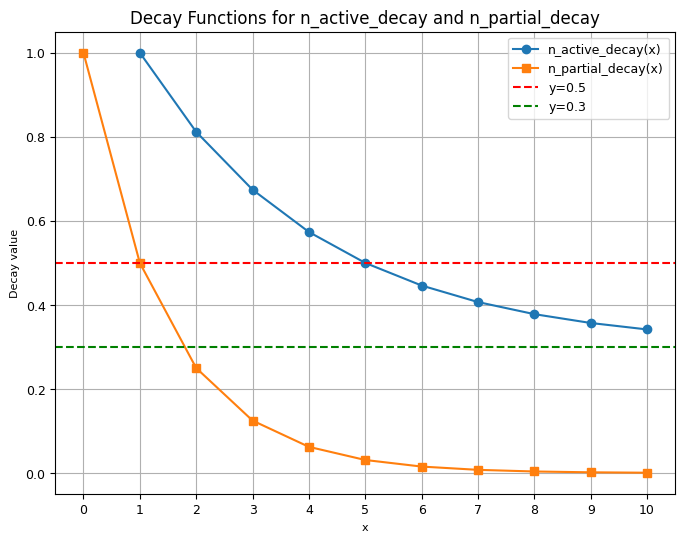

In [ ]:
# Decay functions are imported from scoring_helpers; this cell only visualizes them.
x_int = np.arange(0, 11)
y_active = np.array([n_active_decay(xi) if xi != 0 else np.nan for xi in x_int])
y_partial = np.array([n_partial_decay(xi) for xi in x_int])

plt.figure(figsize=(8, 6))
plt.plot(x_int, y_active, marker="o", label="n_active_decay(x)")
plt.plot(x_int, y_partial, marker="s", label="n_partial_decay(x)")
plt.axhline(0.5, color="red", linestyle="--", label="y=0.5")
plt.axhline(0.3, color="green", linestyle="--", label="y=0.3")
plt.xlabel("x")
plt.ylabel("Decay value")
plt.title("Decay Functions for n_active_decay and n_partial_decay")
plt.legend()
plt.grid(True)
plt.xticks(x_int)
plt.show()


In [ ]:
n_partial_decay(1)

np.float64(0.5)

In [ ]:
n_active_decay(5)

np.float64(0.5)

In [ ]:
assignment_scores.head(10)


In [ ]:
all_scores = angles_scores.join(length_scores).join(assignment_scores).join(df_repr_similarity_scores)
all_scores.head()


In [ ]:
all_scores["total_scores"] = all_scores.apply(
	lambda row: sum(row[col] * SCORE_FACTORS[col] for col in SCORE_FACTORS),
	axis=1,
)
all_scores["total_scores"].head(20)


In [ ]:
def plot_all_scores_distr(all_scores):
	"""
	Plot the distribution (histogram) of the 'total_scores' column from all_scores DataFrame or Series.
	"""
	import matplotlib.pyplot as plt

	# Extract the 'total_scores' column, whether all_scores is a Series or DataFrame
	if isinstance(all_scores, dict) or isinstance(all_scores, list):
		raise ValueError("all_scores should be a pandas DataFrame or Series")

	# If all_scores is a Series (as shown in the context)
	if hasattr(all_scores, 'name') and all_scores.name == 'total_scores':
		scores = all_scores.values
	else:
		# all_scores is a DataFrame
		scores = all_scores["total_scores"].values

	plt.figure(figsize=(8, 6))
	plt.hist(scores, bins=15, color='mediumseagreen', edgecolor='black', alpha=0.8)
	plt.xlabel('Total Score')
	plt.ylabel('Number of Neuron Period Groups')
	plt.title('Distribution of Total Scores')
	plt.grid(True, linestyle='--', alpha=0.7)
	plt.tight_layout()
	plt.show()

plot_all_scores_distr(all_scores)